#**Data Preparation**

In [ ]:
import ssl
import certifi
import os

# Use certifi's certificates for this session
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

%pip install langdetect
from langdetect import detect

from nltk.corpus import wordnet
from sklearn.preprocessing import LabelEncoder


[nltk_data] Downloading package stopwords to /Users/preye/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/preye/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/preye/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/preye/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import re
from nltk.corpus.reader import Lemma

import nltk
nltk.download('averaged_perceptron_tagger_eng')

nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/preye/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /Users/preye/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/preye/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
import seaborn as sb
import matplotlib.pyplot as plt

In [ ]:
%pip install nltk spacy emoji


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
ct = pd.read_csv('cyberbullying_tweets.csv', encoding='latin1')

In [ ]:
ct.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [ ]:
ct.isnull().sum()

tweet_text            0
cyberbullying_type    0
dtype: int64

In [ ]:
ct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


In [ ]:
# Displays random sampling from the dataset
ct.sample(10)

,tweet_text,cyberbullying_type
27485,I'm not really concerned about them being here...,other_cyberbullying
23370,"And the otherwise Atheists , now support radic...",religion
27823,Haaaaaaappy Birthdaaaaaaay bully @MackinxStack...,other_cyberbullying
3304,#mkr 3 the girls are gonna be pissed about that,not_cyberbullying
41760,â@fuck_mexicans: LET ME FIND OUT THAT FUCKIN...,ethnicity
18443,A Pakistani court has sentenced 86 members of ...,religion
40020,(Acts 29:17793) TO destroy those people which ...,ethnicity
27673,It's cool. I'm sure @wadhwa is going to say NP...,other_cyberbullying
46448,@aardvarkwizard itâs encoded racismâ whene...,ethnicity
33607,"This will always be apart of your life, girls ...",age


In [ ]:
ct.shape

(47692, 2)

In [ ]:
#Describe the cyberbullying_type column

ct['cyberbullying_type'].describe()

count        47692
unique           6
top       religion
freq          7998
Name: cyberbullying_type, dtype: object

In [ ]:
# counts the frequency of cyberbullying_type

ct.groupby('cyberbullying_type').count()

,tweet_text
cyberbullying_type,
age,7992
ethnicity,7961
gender,7973
not_cyberbullying,7945
other_cyberbullying,7823
religion,7998


In [ ]:
Percentage = (ct['cyberbullying_type'].value_counts(normalize=True) * 100).round(2)
Percentage

cyberbullying_type
religion               16.77
age                    16.76
gender                 16.72
ethnicity              16.69
not_cyberbullying      16.66
other_cyberbullying    16.40
Name: proportion, dtype: float64

In [ ]:
#Learning NLTK (would delete)
#text = "Hello world! This is NLTK. It's amazing."
#words = nltk.word_tokenize(text)
#sentences = nltk.sent_tokenize(text)

#print("Words:", words)
#print("Sentences:", sentences)

In [ ]:
tt = ct['tweet_text']
ct['tweet_text'] = tt.str.lower()
tt

0        In other words #katandandre, your food was cra...
1        Why is #aussietv so white? #MKR #theblock #ImA...
2        @XochitlSuckkks a classy whore? Or more red ve...
3        @Jason_Gio meh. :P  thanks for the heads up, b...
4        @RudhoeEnglish This is an ISIS account pretend...
                               ...                        
47687    Black ppl aren't expected to do anything, depe...
47688    Turner did not withhold his disappointment. Tu...
47689    I swear to God. This dumb nigger bitch. I have...
47690    Yea fuck you RT @therealexel: IF YOURE A NIGGE...
47691    Bro. U gotta chill RT @CHILLShrammy: Dog FUCK ...
Name: tweet_text, Length: 47692, dtype: object

In [ ]:
cat = ct['cyberbullying_type'].unique()
cat

array(['not_cyberbullying', 'gender', 'religion', 'other_cyberbullying',
       'age', 'ethnicity'], dtype=object)

In [ ]:
tt_c = ct['tweet_text'].str.replace(r'http\S+', '', regex=True)   #removes URLs
tt_c = tt_c.str.replace(r'@[^\s]+', '', regex=True)   #removes @mentions
tt_c = tt_c.str.replace(r'#\w+', '', regex=True)      #removes hashtags
tt_c = tt_c.str.replace(r'[^\w\s]', '', regex=True)   #removes punctuation/special characters
tt_c = tt_c.str.replace(r'\d+', '', regex=True)       #removes digits
tt_c = tt_c.str.replace(r'\s+', ' ', regex=True)      #removes extra spaces
tt_c = tt_c.astype(object)  # use Python regex (supports \1)
tt_c = tt_c.str.replace(r'\b(\w+)(?:\s+\1\b)+', r'\1', regex=True)  # removes repeated words
tt_c = tt_c.str.replace(r'\b(\w+)(?:\s+\1\b)+', r'\1', regex=True) #removes repeated words

tt_c

0               in other words your food was crapilicious 
1                                         why is so white 
2               a classy whore or more red velvet cupcakes
3         meh p thanks for the heads up but not too con...
4         this is an isis account pretending to be a ku...
                               ...                        
47687    black ppl arent expected to do anything depend...
47688    turner did not withhold his disappointment tur...
47689    i swear to god this dumb nigger bitch i have g...
47690    yea fuck you rt if youre a nigger fucking unfo...
47691    bro u gotta chill rt dog fuck kp that dumb nig...
Name: tweet_text, Length: 47692, dtype: object

In [ ]:
tt_c

0               in other words your food was crapilicious 
1                                         why is so white 
2               a classy whore or more red velvet cupcakes
3         meh p thanks for the heads up but not too con...
4         this is an isis account pretending to be a ku...
                               ...                        
47687    black ppl arent expected to do anything depend...
47688    turner did not withhold his disappointment tur...
47689    i swear to god this dumb nigger bitch i have g...
47690    yea fuck you rt if youre a nigger fucking unfo...
47691    bro u gotta chill rt dog fuck kp that dumb nig...
Name: tweet_text, Length: 47692, dtype: object

/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/4224792574.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(


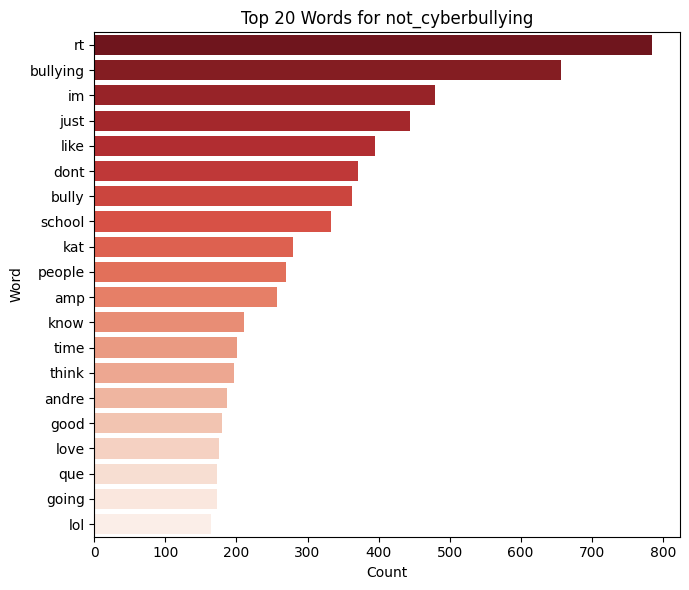

/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/4224792574.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(


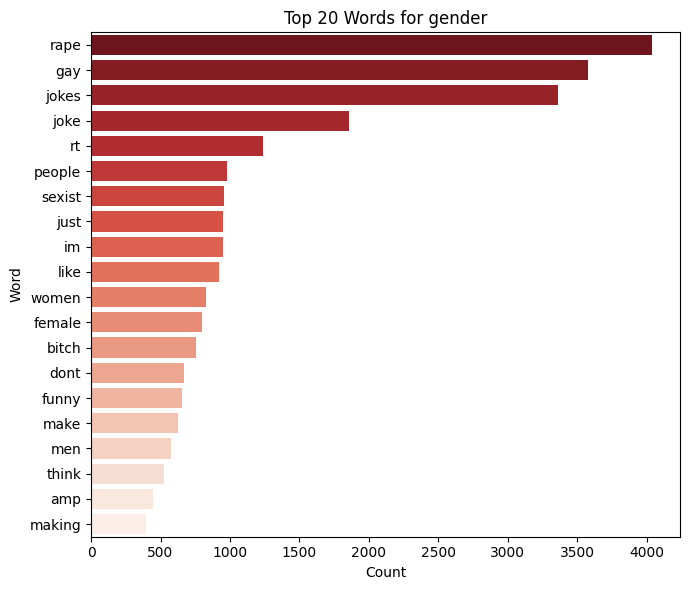

/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/4224792574.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(


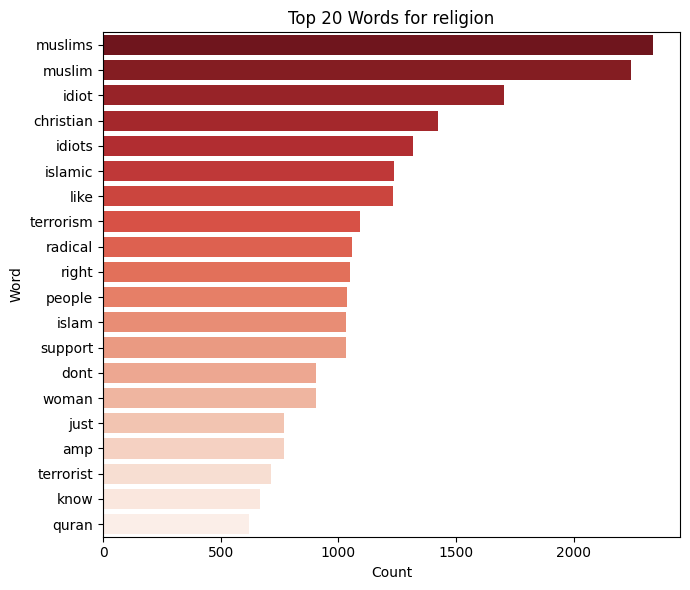

/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/4224792574.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(


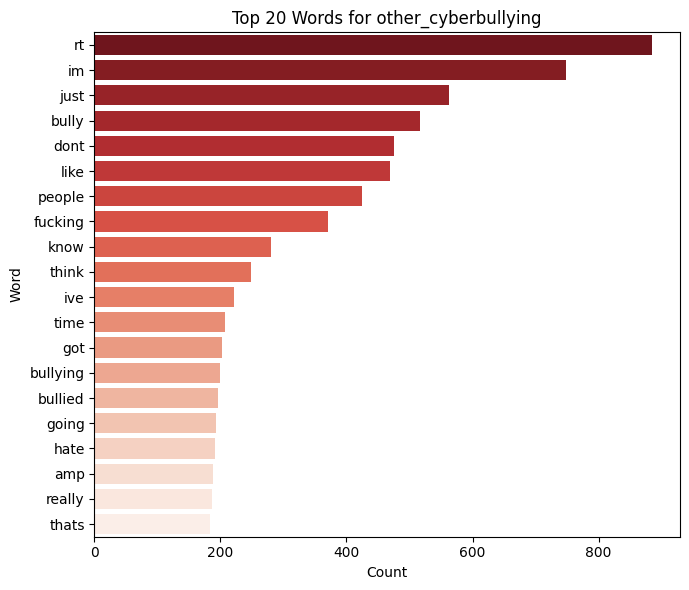

/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/4224792574.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(


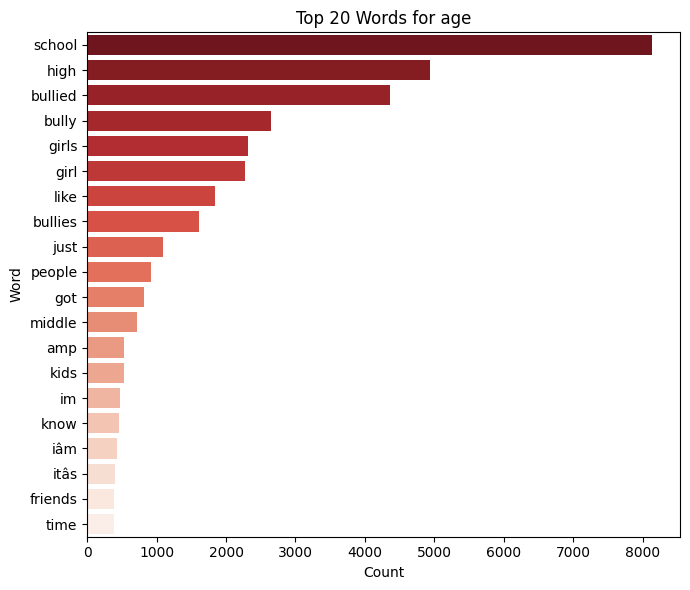

/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/4224792574.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(


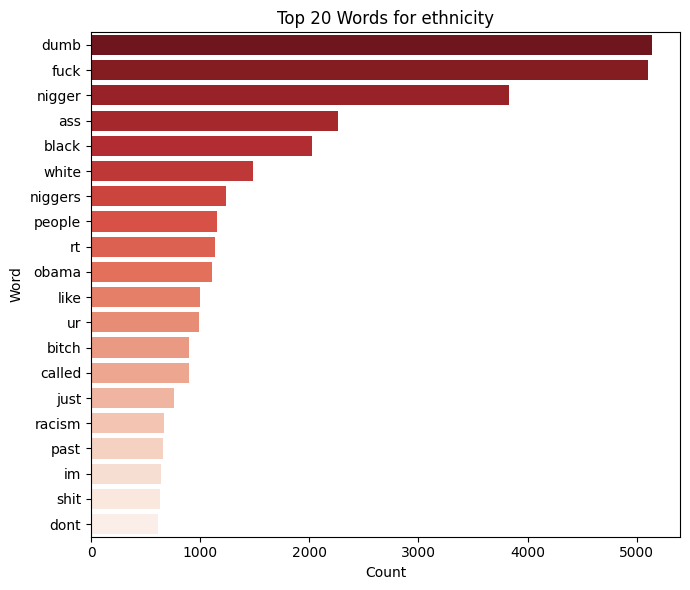

In [ ]:
#from sklearn.feature_extraction.text import CountVectorizer

unique_categories = ct['cyberbullying_type'].unique()

for category in unique_categories:
    subset = ct[ct['cyberbullying_type'] == category]

    # Clean text
    texts_for_vectorizer = (
        tt_c.loc[subset.index] # Correctly access the tt_c Series by subset's index
        .dropna()
        .astype(str)
        .apply(lambda x: x.strip())
        .loc[lambda s: s != '']
    )

    if texts_for_vectorizer.empty:
        print(f"Skipping plotting for '{category}' as no valid texts remain after cleaning and filtering.")
        continue

    vec = CountVectorizer(stop_words='english', max_features=20)

    try:
        X = vec.fit_transform(texts_for_vectorizer)
        words = vec.get_feature_names_out()

        if len(words) == 0:
            print(f"Skipping plotting for '{category}' as no meaningful vocabulary could be formed after stop word removal.")
            continue

        word_counts = X.sum(axis=0)
        counts = word_counts.tolist()[0]

        word_freq_df = (
            pd.DataFrame({'word': words, 'count': counts})
            .sort_values(by='count', ascending=False)
        )

        # ┅ NEW: one figure per category
        plt.figure(figsize=(7, 6))
        sb.barplot(
            x='count',
            y='word',
            data=word_freq_df,
            palette='Reds_r'
        )
        plt.title(f'Top 20 Words for {category}')
        plt.xlabel('Count')
        plt.ylabel('Word')
        plt.tight_layout()

        # ┅ OPTIONAL: save each plot as its own image
        safe_name = str(category).replace(' ', '_')
        plt.savefig(f"top20_words_{safe_name}.png", dpi=300)

        plt.show()

    except ValueError as e:
        print(f"An unexpected error occurred for category '{category}' during vectorization: {e}")
        continue


In [ ]:
Lemma = WordNetLemmatizer()

tt_lm = tt_c.apply(lambda x: ' '.join(Lemma.lemmatize(word) for word in x.split()))
tt_lm

0                  in other word your food wa crapilicious
1                                          why is so white
2                a classy whore or more red velvet cupcake
3        meh p thanks for the head up but not too conce...
4        this is an isi account pretending to be a kurd...
                               ...                        
47687    black ppl arent expected to do anything depend...
47688    turner did not withhold his disappointment tur...
47689    i swear to god this dumb nigger bitch i have g...
47690    yea fuck you rt if youre a nigger fucking unfo...
47691    bro u gotta chill rt dog fuck kp that dumb nig...
Name: tweet_text, Length: 47692, dtype: object

In [ ]:
#This is to check the full text to examine the application of Lemmitization without POS tag
tt_lm[0]

'in other word your food wa crapilicious'

In [ ]:
#This is to compare it with cleaned version of the raw tweet text
tt_c[0]

'in other words your food was crapilicious '

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

def get_wordnet_pos(word):
  tag = nltk.pos_tag([word])[0][1][0].upper()
  tag_dict = {
      "J": wordnet.ADJ,
      "N": wordnet.NOUN,
      "V": wordnet.VERB,
      "R": wordnet.ADV
  }
  return tag_dict.get(tag, wordnet.NOUN)


lemma = WordNetLemmatizer()
tt_lem = tt_c.apply(lambda x: ' '.join(lemma.lemmatize(w, get_wordnet_pos(w)) for w in x.split()))
tt_lem[:5]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/preye/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


0              in other word your food be crapilicious
1                                      why be so white
2            a classy whore or more red velvet cupcake
3    meh p thanks for the head up but not too conce...
4    this be an isi account pretend to be a kurdish...
Name: tweet_text, dtype: object

In [ ]:
print(tt_lem[4]) #lemmitization with POS tag
print(tt_c[4]) # cleaned tweet text without lemmitization
print(tt_lm[4]) #lemmitization without POS tag

this be an isi account pretend to be a kurdish account like islam it be all lie
 this is an isis account pretending to be a kurdish account like islam it is all lies
this is an isi account pretending to be a kurdish account like islam it is all lie


In [ ]:
stop_words = set(stopwords.words('english'))
tt_csw = tt_c.apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

In [ ]:
ct['tt_lem'] = tt_lem
ct['tweet_text'] = tt_c
ct['tt_csw'] = tt_csw

tweets = list(zip(ct['tweet_text'], ct['tt_lem'], ct['tt_csw'], ct['cyberbullying_type']))

tweets = pd.DataFrame(tweets, columns=['tweet_text', 'tt_lem', 'tt_csw', 'cyberbullying_type'])
tweets

,tweet_text,tt_lem,tt_csw,cyberbullying_type
0,in other words your food was crapilicious,in other word your food be crapilicious,words food crapilicious,not_cyberbullying
1,why is so white,why be so white,white,not_cyberbullying
2,a classy whore or more red velvet cupcakes,a classy whore or more red velvet cupcake,classy whore red velvet cupcakes,not_cyberbullying
3,meh p thanks for the heads up but not too con...,meh p thanks for the head up but not too conce...,meh p thanks heads concerned another angry dud...,not_cyberbullying
4,this is an isis account pretending to be a ku...,this be an isi account pretend to be a kurdish...,isis account pretending kurdish account like i...,not_cyberbullying
...,...,...,...,...
47687,black ppl arent expected to do anything depend...,black ppl arent expect to do anything depend o...,black ppl arent expected anything depended any...,ethnicity
47688,turner did not withhold his disappointment tur...,turner do not withhold his disappointment turn...,turner withhold disappointment turner called c...,ethnicity
47689,i swear to god this dumb nigger bitch i have g...,i swear to god this dumb nigger bitch i have g...,swear god dumb nigger bitch got bleach hair re...,ethnicity
47690,yea fuck you rt if youre a nigger fucking unfo...,yea fuck you rt if youre a nigger fuck unfollo...,yea fuck rt youre nigger fucking unfollow fuck...,ethnicity


#**Baseline Models (Logistic Regression, SVM)**

In [ ]:
ct.head()

,tweet_text,cyberbullying_type,tt_lem,tt_csw
0,in other words your food was crapilicious,not_cyberbullying,in other word your food be crapilicious,words food crapilicious
1,why is so white,not_cyberbullying,why be so white,white
2,a classy whore or more red velvet cupcakes,not_cyberbullying,a classy whore or more red velvet cupcake,classy whore red velvet cupcakes
3,meh p thanks for the heads up but not too con...,not_cyberbullying,meh p thanks for the head up but not too conce...,meh p thanks heads concerned another angry dud...
4,this is an isis account pretending to be a ku...,not_cyberbullying,this be an isi account pretend to be a kurdish...,isis account pretending kurdish account like i...


###**Logistic Regression (LR) -- Clean Text only**

In [ ]:
X = ct['tweet_text']
y = ct['cyberbullying_type']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
tfidf = TfidfVectorizer(min_df=1,binary=False,ngram_range=(1,2), max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

vocab=tfidf.get_feature_names_out()
vocab.shape

(5000,)

In [ ]:
model_lr = LogisticRegression()
model_lr.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
y_pred = model_lr.predict(X_test_tfidf)

In [ ]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

                     precision    recall  f1-score   support

                age       0.97      0.97      0.97      1603
          ethnicity       0.98      0.97      0.97      1603
             gender       0.89      0.81      0.85      1531
  not_cyberbullying       0.54      0.54      0.54      1624
other_cyberbullying       0.56      0.62      0.59      1612
           religion       0.94      0.93      0.94      1566

           accuracy                           0.81      9539
          macro avg       0.81      0.81      0.81      9539
       weighted avg       0.81      0.81      0.81      9539

[[1549    1    5   24   22    2]
 [   3 1552    5   12   28    3]
 [   3    5 1235  151  128    9]
 [  35    8   65  878  581   57]
 [  12    9   71  496 1007   17]
 [   2    6    9   61   28 1460]]
0.8052206730265227


<Axes: >

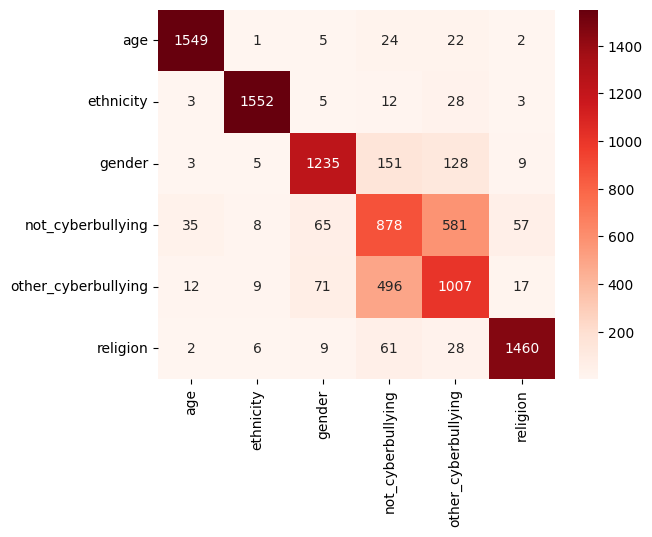

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred)
sb.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', xticklabels=['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion'], yticklabels=['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion'])

In [ ]:
feature_names = tfidf.get_feature_names_out()
classes_lr = model_lr.classes_

/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/1607676770.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='coefficient', y='word', data=feat_ct, ax=axes[i], palette='Reds_r')
/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/1607676770.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='coefficient', y='word', data=feat_ct, ax=axes[i], palette='Reds_r')
/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/1607676770.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='coefficient', y='w

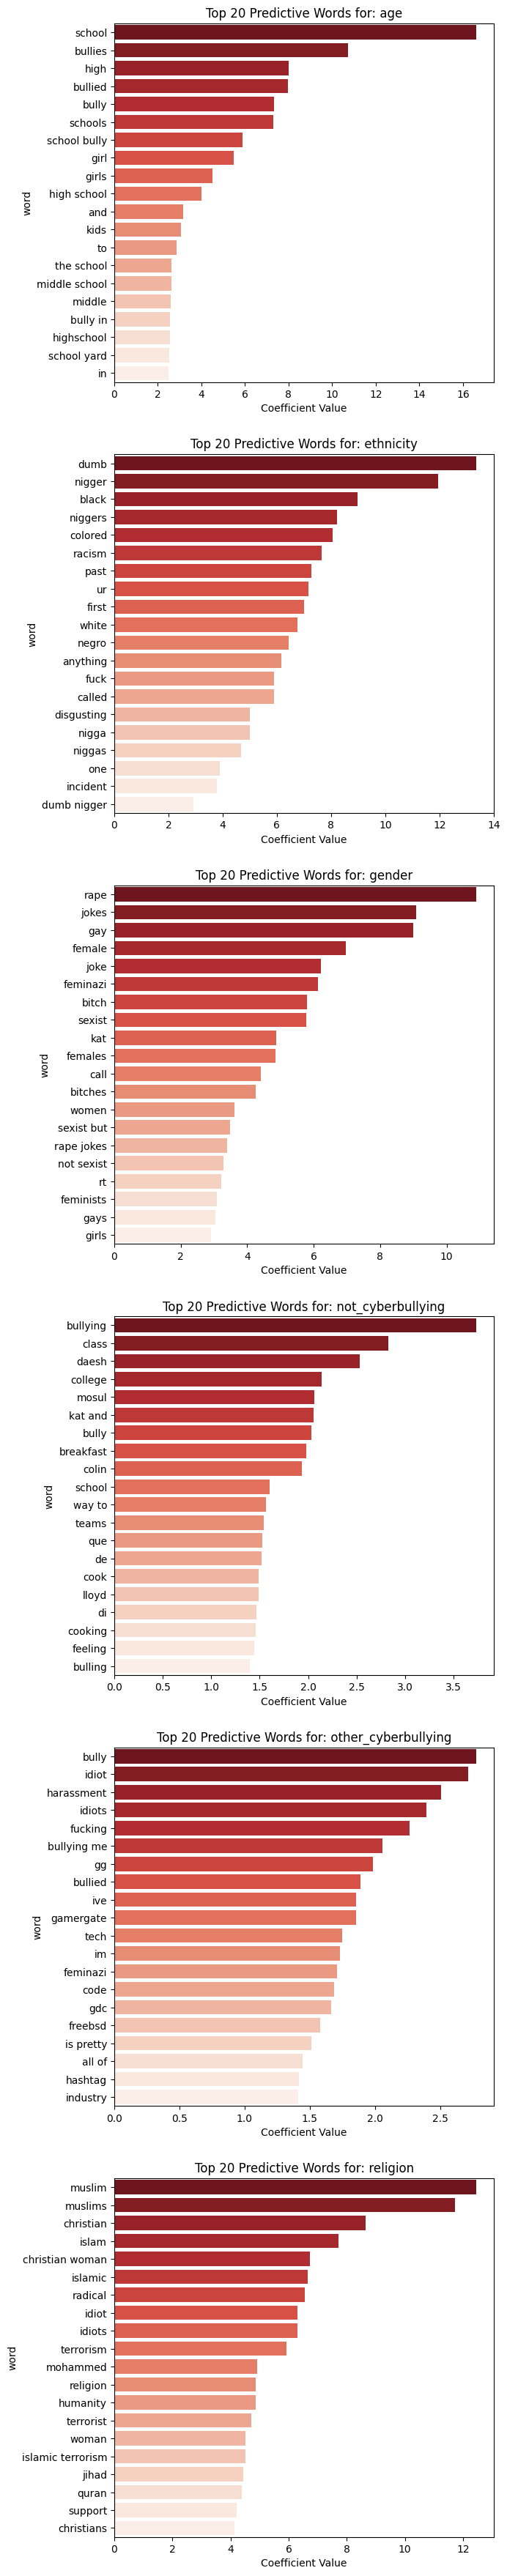

In [ ]:
fig, axes = plt.subplots(nrows=len(classes_lr), ncols=1, figsize=(7, 6 * len(classes_lr)))
fig.tight_layout(pad=5.0)

for i, class_label in enumerate(classes_lr):
    class_coefficients = model_lr.coef_[i]
    top_indices = np.argsort(class_coefficients)[-20:] # Top 20 positive coeffs

    top_words = [feature_names[j] for j in top_indices]
    top_scores = class_coefficients[top_indices]

    feat_ct = pd.DataFrame({'word': top_words, 'coefficient': top_scores}).sort_values(by='coefficient', ascending=False)

    sb.barplot(x='coefficient', y='word', data=feat_ct, ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'Top 20 Predictive Words for: {class_label}')
    axes[i].set_xlabel('Coefficient Value')

In [ ]:
ct_test = pd.DataFrame({'text': X_test, 'true': y_test, 'pred': y_pred})
errors = ct_test[ct_test['true'] != ct_test['pred']]
errors.sample(20)

,text,true,pred
26353,rt,other_cyberbullying,gender
1188,watching other bsd devs tell roguestar hes wro...,not_cyberbullying,other_cyberbullying
673,my phones at im going to cry,not_cyberbullying,other_cyberbullying
13571,already sick of hearing pretty,gender,not_cyberbullying
29028,rt the part of the law and order episode that ...,other_cyberbullying,religion
1162,i dont know what an atmospheric river is but ...,not_cyberbullying,other_cyberbullying
27980,but a woman who knows how toãââ,other_cyberbullying,religion
29942,al final me pondrãn el nombre de sara odiahomb...,other_cyberbullying,not_cyberbullying
7831,rt thank god weve finally got to the point in ...,not_cyberbullying,other_cyberbullying
22716,come back for a chat when you get a brain,religion,not_cyberbullying


###**Logistic Regression (LR) -- Clean Text with Lemmitization**

In [ ]:
Xl = ct['tt_lem']
yl = ct['cyberbullying_type']

In [ ]:
Xl_train, Xl_test, yl_train, yl_test = train_test_split(Xl, yl, test_size=0.2, random_state=42)

In [ ]:
tfidf = TfidfVectorizer(min_df=1,binary=False,ngram_range=(1,2), max_features=5000)
Xl_train_tfidf = tfidf.fit_transform(Xl_train)
Xl_test_tfidf = tfidf.transform(Xl_test)

vocabl=tfidf.get_feature_names_out()
vocabl.shape

(5000,)

In [ ]:
model_lrl = LogisticRegression()
model_lrl.fit(Xl_train_tfidf, yl_train)

/Users/preye/tf-metal-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
yl_pred = model_lrl.predict(Xl_test_tfidf)

In [ ]:
print(classification_report(yl_test, yl_pred))
print(confusion_matrix(yl_test, yl_pred))
print(accuracy_score(yl_test, yl_pred))

                     precision    recall  f1-score   support

                age       0.96      0.97      0.96      1603
          ethnicity       0.98      0.97      0.98      1603
             gender       0.88      0.82      0.85      1531
  not_cyberbullying       0.54      0.54      0.54      1624
other_cyberbullying       0.57      0.62      0.60      1612
           religion       0.95      0.93      0.94      1566

           accuracy                           0.81      9539
          macro avg       0.81      0.81      0.81      9539
       weighted avg       0.81      0.81      0.81      9539

[[1552    1    4   26   17    3]
 [   3 1551    8   13   23    5]
 [   2    7 1251  143  122    6]
 [  45    6   79  885  558   51]
 [  17    4   76  500 1000   15]
 [   2    6    8   67   23 1460]]
0.8071076632770731


<Axes: >

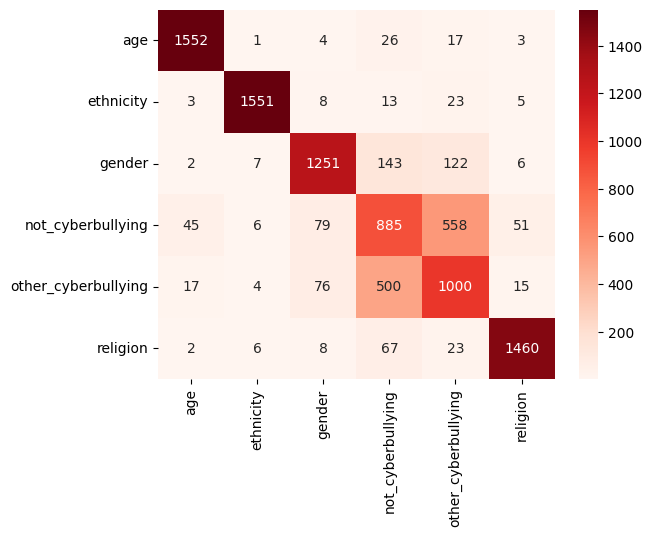

In [ ]:
cm_lrl = confusion_matrix(yl_test, yl_pred)
sb.heatmap(cm_lrl, annot=True, fmt='d', cmap='Reds', xticklabels=['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion'], yticklabels=['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion'])

In [ ]:
feature_names = tfidf.get_feature_names_out()
classes_lrl = model_lrl.classes_

/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/554155081.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='coefficient', y='word', data=feat_ct, ax=axes[i], palette='Reds_r')
/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/554155081.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='coefficient', y='word', data=feat_ct, ax=axes[i], palette='Reds_r')
/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/554155081.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='coefficient', y='word

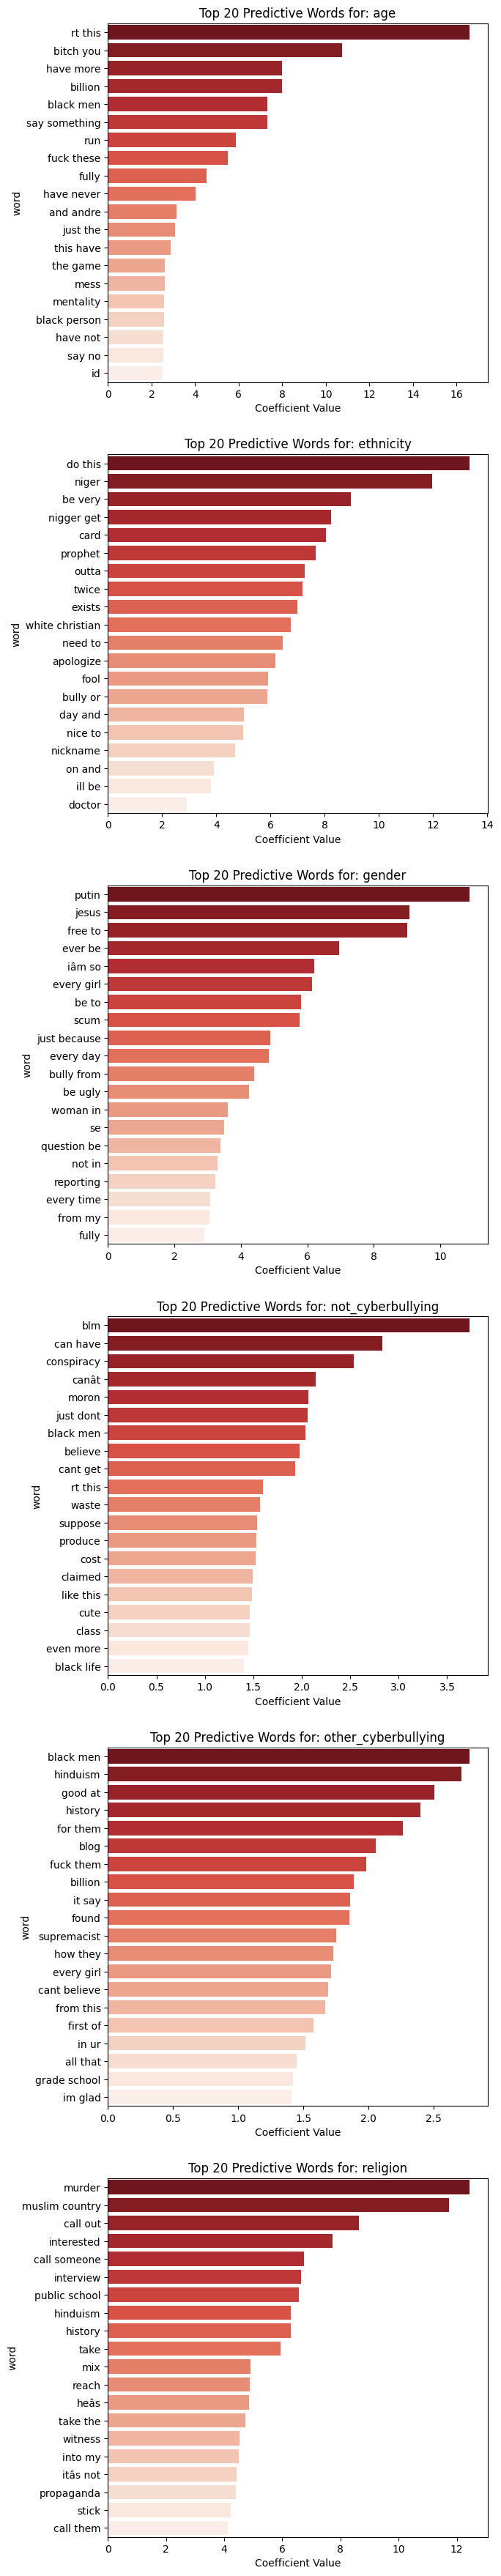

In [ ]:
fig, axes = plt.subplots(nrows=len(classes_lrl), ncols=1, figsize=(7, 6 * len(classes_lrl)))
fig.tight_layout(pad=5.0)

for i, class_label in enumerate(classes_lr):
    class_coefficients = model_lr.coef_[i]
    top_indices = np.argsort(class_coefficients)[-20:] # Top 20 positive coeffs

    top_words = [feature_names[j] for j in top_indices]
    top_scores = class_coefficients[top_indices]

    feat_ct = pd.DataFrame({'word': top_words, 'coefficient': top_scores}).sort_values(by='coefficient', ascending=False)

    sb.barplot(x='coefficient', y='word', data=feat_ct, ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'Top 20 Predictive Words for: {class_label}')
    axes[i].set_xlabel('Coefficient Value')

In [ ]:
ctl_test = pd.DataFrame({'text': Xl_test, 'true': yl_test, 'pred': yl_pred})
errorsl = ctl_test[ctl_test['true'] != ct_test['pred']]
errorsl.sample(20)

,text,true,pred
31392,,other_cyberbullying,not_cyberbullying
28520,,other_cyberbullying,not_cyberbullying
37349,yes those bully be make thing x bad aaa,age,other_cyberbullying
3272,rt oh come on theyre not even try to hide thei...,not_cyberbullying,other_cyberbullying
13399,why cant you tell,gender,other_cyberbullying
30700,awesome cant wait to hear from you,other_cyberbullying,not_cyberbullying
3488,rt and at on this stream he say people in gg s...,not_cyberbullying,other_cyberbullying
30920,the sassy food feel these girl be vile people,other_cyberbullying,not_cyberbullying
30475,rt troll from chan try to sabotage amaze kicks...,other_cyberbullying,not_cyberbullying
29005,,other_cyberbullying,not_cyberbullying


In [ ]:
ctl_test = pd.DataFrame({'text': Xl_test, 'true': yl_test, 'pred': yl_pred})

errors = ctl_test[ctl_test['true'] != ctl_test['pred']]

lmisclass_counts = errors.groupby(['true', 'pred']).size().reset_index(name='count')

lmisclass_counts = lmisclass_counts.sort_values(by='count', ascending=False)

lmisclass_counts.head(10)

,true,pred,count
18,not_cyberbullying,other_cyberbullying,558
23,other_cyberbullying,not_cyberbullying,500
12,gender,not_cyberbullying,143
13,gender,other_cyberbullying,122
17,not_cyberbullying,gender,79
22,other_cyberbullying,gender,76
28,religion,not_cyberbullying,67
19,not_cyberbullying,religion,51
15,not_cyberbullying,age,45
2,age,not_cyberbullying,26


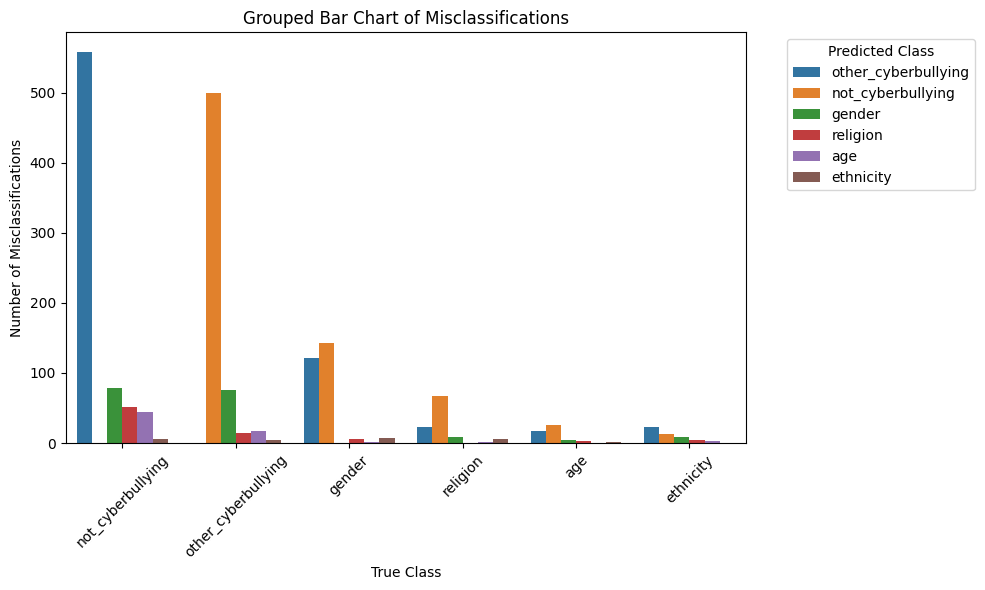

In [ ]:
#import matplotlib.pyplot as plt

# Assuming this is already created:
# misclass_counts = errors.groupby(['true', 'pred']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sb.barplot(data=lmisclass_counts, x='true', y='count', hue='pred')

plt.title('Grouped Bar Chart of Misclassifications')
plt.ylabel('Number of Misclassifications')
plt.xlabel('True Class')
plt.xticks(rotation=45)
plt.legend(title='Predicted Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/119532716.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=top_n, x='pair', y='count', palette='rocket')


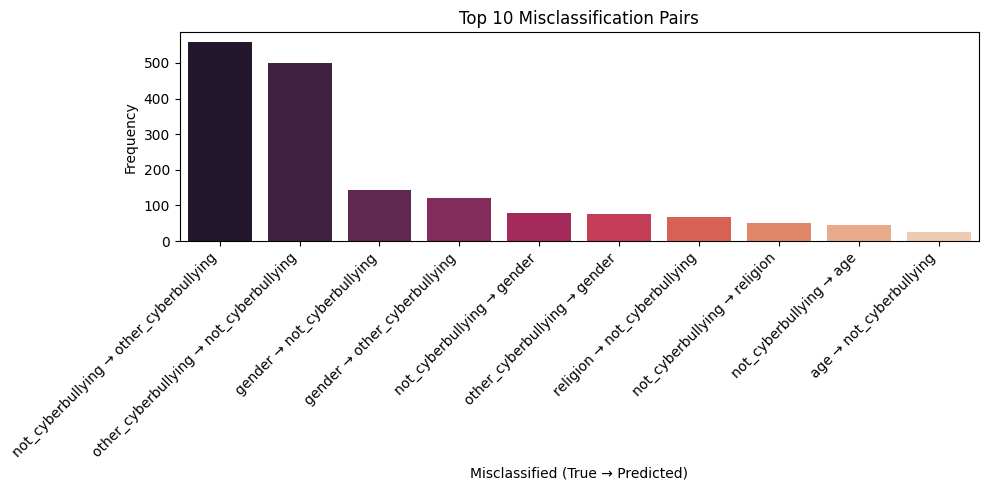

In [ ]:
top_n = lmisclass_counts.sort_values(by='count', ascending=False).head(10)
top_n['pair'] = top_n['true'] + ' → ' + top_n['pred']

plt.figure(figsize=(10, 5))
sb.barplot(data=top_n, x='pair', y='count', palette='rocket')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Misclassification Pairs")
plt.ylabel("Frequency")
plt.xlabel("Misclassified (True → Predicted)")
plt.tight_layout()
plt.show()

/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_11892/76907262.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=per_class_miss, x='true_label', y='misclassified_count', palette='mako')


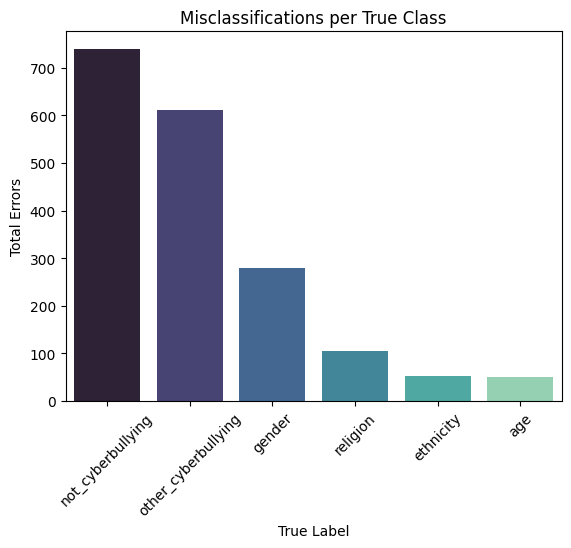

In [ ]:
# Count how many times each class was the true label in a misclassification
per_class_miss = errors['true'].value_counts().reset_index()
per_class_miss.columns = ['true_label', 'misclassified_count']

sb.barplot(data=per_class_miss, x='true_label', y='misclassified_count', palette='mako')
plt.title("Misclassifications per True Class")
plt.ylabel("Total Errors")
plt.xlabel("True Label")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [500, 1000, 2000],
    'solver': ['saga', 'newton-cg', 'lbfgs']
}

grid = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000), param_grid, cv=5, scoring='f1_weighted')
grid.fit(Xl_train_tfidf, yl_train)

best_model = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'C': 1, 'max_iter': 1000, 'solver': 'saga'}


In [ ]:
from sklearn.metrics import classification_report

y_pred_tuned = best_model.predict(Xl_test_tfidf)
print(classification_report(yl_test, y_pred_tuned))

                     precision    recall  f1-score   support

                age       0.96      0.97      0.96      1603
          ethnicity       0.98      0.97      0.98      1603
             gender       0.88      0.82      0.85      1531
  not_cyberbullying       0.54      0.54      0.54      1624
other_cyberbullying       0.57      0.63      0.60      1612
           religion       0.95      0.93      0.94      1566

           accuracy                           0.81      9539
          macro avg       0.81      0.81      0.81      9539
       weighted avg       0.81      0.81      0.81      9539



Logistic Regression (Stopword)

In [ ]:
Xsw = ct['tt_csw']
ysw = ct['cyberbullying_type']

In [ ]:
Xsw_train, Xsw_test, ysw_train, ysw_test = train_test_split(Xsw, ysw, test_size=0.2, random_state=42)

In [ ]:
tfidf = TfidfVectorizer(min_df=1,binary=False,ngram_range=(1,2), max_features=5000)
Xsw_train_tfidf = tfidf.fit_transform(Xsw_train)
Xsw_test_tfidf = tfidf.transform(Xsw_test)

vocabl=tfidf.get_feature_names_out()
vocabl.shape

(5000,)

In [ ]:
model_lrsw = LogisticRegression()
model_lrsw.fit(Xsw_train_tfidf, ysw_train)
ysw_pred = model_lrsw.predict(Xsw_test_tfidf)

/Users/preye/tf-metal-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print(classification_report(ysw_test, ysw_pred))
print(confusion_matrix(ysw_test, ysw_pred))
print(accuracy_score(ysw_test, ysw_pred))

                     precision    recall  f1-score   support

                age       0.96      0.96      0.96      1603
          ethnicity       0.98      0.97      0.97      1603
             gender       0.88      0.81      0.84      1531
  not_cyberbullying       0.54      0.56      0.55      1624
other_cyberbullying       0.58      0.63      0.60      1612
           religion       0.96      0.93      0.94      1566

           accuracy                           0.81      9539
          macro avg       0.82      0.81      0.81      9539
       weighted avg       0.82      0.81      0.81      9539

[[1537    0    5   38   22    1]
 [   2 1554    6   13   26    2]
 [   2    4 1236  159  125    5]
 [  43   14   66  906  547   48]
 [   8   12   75  486 1019   12]
 [   2    2    9   69   29 1455]]
0.807946325610651


<Axes: >

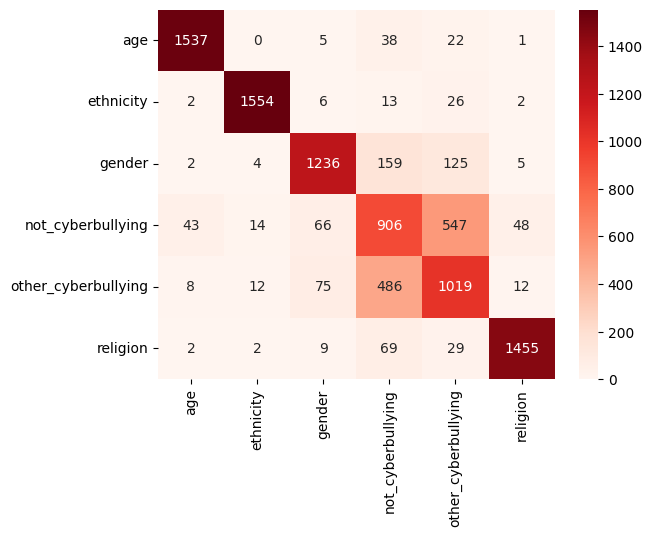

In [ ]:
cm_lrsw = confusion_matrix(ysw_test, ysw_pred)
sb.heatmap(cm_lrsw, annot=True, fmt='d', cmap='Reds', xticklabels=['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion'], yticklabels=['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion'])

###**Support Vector Machine (SVM) -- Non Neural Baseline**

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
#from sklearn.feature_extraction.text import TfidfVectorizer
#from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 1))),
    ('svm', LinearSVC(class_weight='balanced', C=0.1))
])

In [ ]:
svm_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [ ]:
y_pred_svm = svm_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(accuracy_score(y_test, y_pred_svm))


                     precision    recall  f1-score   support

                age       0.94      0.98      0.96      1603
          ethnicity       0.97      0.97      0.97      1603
             gender       0.89      0.81      0.85      1531
  not_cyberbullying       0.58      0.51      0.54      1624
other_cyberbullying       0.59      0.67      0.63      1612
           religion       0.93      0.94      0.94      1566

           accuracy                           0.81      9539
          macro avg       0.82      0.82      0.81      9539
       weighted avg       0.82      0.81      0.81      9539

[[1565    0    4   14   16    4]
 [   3 1557    6   11   21    5]
 [   3    7 1239  149  122   11]
 [  63   17   64  836  580   64]
 [  18   18   74  392 1088   22]
 [   5    4   10   44   24 1479]]
0.8139217947373939


In [ ]:
svm_pipelinel = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 1))),
    ('svm', LinearSVC(class_weight='balanced', C=0.1))
])

In [ ]:
svm_pipelinel.fit(Xl_train, yl_train)

,steps,"[('tfidf', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [ ]:
yl_pred_svm = svm_pipeline.predict(Xl_test)
print(classification_report(yl_test, yl_pred_svm))
print(accuracy_score(yl_test, yl_pred_svm))
print(confusion_matrix(yl_test, yl_pred_svm))

                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      1603
          ethnicity       0.96      0.96      0.96      1603
             gender       0.88      0.80      0.84      1531
  not_cyberbullying       0.54      0.54      0.54      1624
other_cyberbullying       0.57      0.60      0.59      1612
           religion       0.92      0.94      0.93      1566

           accuracy                           0.80      9539
          macro avg       0.80      0.80      0.80      9539
       weighted avg       0.80      0.80      0.80      9539

0.8009225285669357
[[1560    1    4   19   16    3]
 [   5 1537   16   14   23    8]
 [   3    6 1230  162  111   19]
 [  59   16   59  869  551   70]
 [  15   27   84  485  972   29]
 [   3    9    8   55   19 1472]]


In [ ]:
param_grid = {
    'svm__C': [0.1, 1, 10],
    'tfidf__ngram_range': [(1, 1), (1, 2)]
}

grid = GridSearchCV(svm_pipeline, param_grid, scoring='f1_weighted', cv=3)
grid.fit(X_train, y_train)

best_svm = grid.best_estimator_
print("Best params:", grid.best_params_)


Best params: {'svm__C': 0.1, 'tfidf__ngram_range': (1, 1)}


In [ ]:
param_grid = {
    'svm__C': [0.1, 1, 10],
    'tfidf__ngram_range': [(1, 1), (1, 2)]
}

grid = GridSearchCV(svm_pipelinel, param_grid, scoring='f1_weighted', cv=10)
grid.fit(Xl_train, yl_train)

best_svm = grid.best_estimator_
print("Best params:", grid.best_params_)


Best params: {'svm__C': 0.1, 'tfidf__ngram_range': (1, 1)}


In [ ]:
# Combine text, true, and predicted labels
svm_results = pd.DataFrame({
    'text': X_test,
    'true': y_test,
    'pred': y_pred_svm
})

# Filter misclassified tweets
svm_errors = svm_results[svm_results['true'] != svm_results['pred']]
svm_errors.sample(10)  # View 10 random misclassifications

,text,true,pred
9981,ð no it isnât,gender,not_cyberbullying
30369,yes but theyll call you one if they catch you ...,other_cyberbullying,gender
24311,i like ladies more than i like men that might...,other_cyberbullying,gender
2814,it sure is weird how i only ever see mean thin...,not_cyberbullying,other_cyberbullying
18110,we want society but are killing us for,religion,other_cyberbullying
23969,rt isis calls trump an idiot and tells us to a...,other_cyberbullying,religion
8784,was your previous praise tactical or just mis...,gender,other_cyberbullying
29384,so gabby eat ass,other_cyberbullying,not_cyberbullying
5711,the real work is just getting started,not_cyberbullying,other_cyberbullying
15480,bullshit kat amp andre you are deadset cunts,gender,not_cyberbullying


In [ ]:
misclass_counts = svm_errors.groupby(['true', 'pred']).size().reset_index(name='count')
misclass_counts.sort_values(by='count', ascending=False).head(10)

,true,pred,count
17,not_cyberbullying,other_cyberbullying,580
22,other_cyberbullying,not_cyberbullying,392
11,gender,not_cyberbullying,149
12,gender,other_cyberbullying,122
21,other_cyberbullying,gender,74
18,not_cyberbullying,religion,64
16,not_cyberbullying,gender,64
14,not_cyberbullying,age,63
27,religion,not_cyberbullying,44
28,religion,other_cyberbullying,24


#**Deep Learning Models (CNN/LSTM, BERT)**

###**CNN/LSTM Hybrid Model**

In [ ]:
  import sys
  print(sys.executable)

/Users/preye/tf-metal-env/bin/python


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import os
import zipfile
import requests

In [ ]:
# model.add(Dense(len(set(y_train)), activation='softmax'))

In [ ]:
# Parameters
MAX_NUM_WORDS = 10000
MAX_SEQUENCE_LENGTH = 100
EMBEDDING_DIM = 100

# Tokenize text
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS)
tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_SEQUENCE_LENGTH)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_SEQUENCE_LENGTH)

word_index = tokenizer.word_index
print(f"Found {len(word_index)} unique tokens.")

# Download GloVe 100d
glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_zip_path = "/Users/preye/Downloads/Masters AI:ML/AI for Cyberbullying detection/glove.6B/glove.6B.100d.txt"
# glove_zip_path = "/content/glove.6B.zip"
glove_data_dir = os.path.dirname(glove_zip_path)  # Directory containing the GloVe file
glove_embeddings_file = glove_zip_path  # Path to the embeddings .txt file (using local file)

# Ensure the directory for the GloVe file exists
os.makedirs(glove_data_dir, exist_ok=True)

if not os.path.exists(glove_embeddings_file): # Check if the actual embeddings file exists
    print("Downloading GloVe embeddings...")
    # Download the zip if it doesn't exist
    if not os.path.exists(glove_zip_path):
        try:
            r = requests.get(glove_url, stream=True) # Use stream to handle large files
            r.raise_for_status() # Raise an exception for HTTP errors
            with open(glove_zip_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f"Downloaded GloVe zip to {glove_zip_path}")
        except requests.exceptions.RequestException as e:
            print(f"Error downloading GloVe embeddings: {e}")
            # For now, let's proceed assuming the download might still be possible or file exists.
            pass


    # Extract the zip file
    if os.path.exists(glove_zip_path):
        os.makedirs(glove_data_dir, exist_ok=True) # Ensure extraction directory exists
        with zipfile.ZipFile(glove_zip_path, 'r') as zip_ref:
            zip_ref.extractall(glove_data_dir) # Extract into the target directory
        print(f"Extracted GloVe zip to {glove_data_dir}")

        # After extraction, the actual glove file is often inside a subfolder (e.g., 'glove.6B')
        # Let's check for this common structure and move if necessary
        temp_extracted_path = os.path.join(glove_data_dir, 'glove.6B', 'glove.6B.100d.txt')
        if os.path.exists(temp_extracted_path) and temp_extracted_path != glove_embeddings_file:
            import shutil
            shutil.move(temp_extracted_path, glove_embeddings_file)
            # Clean up the 'glove.6B' directory if it's now empty or no longer needed
            shutil.rmtree(os.path.join(glove_data_dir, 'glove.6B'))
            print(f"Moved glove.6B.100d.txt from subfolder to {glove_embeddings_file}")
        elif not os.path.exists(glove_embeddings_file): # If it wasn't in a subfolder and not directly in glove_data_dir
             print(f"Warning: glove.6B.100d.txt not found at expected paths after extraction. Please check zip content structure.")

    # Clean up the zip file
    if os.path.exists(glove_zip_path):
        os.remove(glove_zip_path)

    print("GloVe embeddings downloaded and extracted.")
else:
    print("GloVe embeddings already exist.")

# Load GloVe embeddings
embeddings_index = {}
with open(glove_embeddings_file, encoding='utf-8') as f: # Use the correct file path here
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Prepare embedding matrix
embedding_matrix = np.zeros((MAX_NUM_WORDS, EMBEDDING_DIM))
for word, i in word_index.items():
    if i < MAX_NUM_WORDS:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Build CNN–LSTM model
model = Sequential()
model.add(Embedding(input_dim=MAX_NUM_WORDS,
                    output_dim=EMBEDDING_DIM,
                    weights=[embedding_matrix],
                    input_shape=(MAX_SEQUENCE_LENGTH,),
                    trainable=False))
model.add(Conv1D(128, 5, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(len(label_encoder.classes_), activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


model.summary()

Found 41137 unique tokens.
GloVe embeddings already exist.


/Users/preye/tf-metal-env/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-03-11 23:00:09.191667: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-03-11 23:00:09.191717: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-11 23:00:09.191726: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-11 23:00:09.191751: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-11 23:00:09.191759: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/repl

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 128)        │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113,926 (4.25 MB)

 Trainable params: 113,926 (445.02 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [ ]:
history = model.fit(
    X_train_seq, y_train_enc,
    validation_data=(X_test_seq, y_test_enc),
    epochs=5,
    batch_size=128
)

Epoch 1/5


2026-03-11 23:00:09.684255: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


299/299 ━━━━━━━━━━━━━━━━━━━━ 943s 3s/step - accuracy: 0.7143 - loss: 0.7150 - val_accuracy: 0.7810 - val_loss: 0.5227
Epoch 2/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 938s 3s/step - accuracy: 0.7906 - loss: 0.4968 - val_accuracy: 0.7862 - val_loss: 0.4939
Epoch 3/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 935s 3s/step - accuracy: 0.8070 - loss: 0.4545 - val_accuracy: 0.7923 - val_loss: 0.4988
Epoch 4/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 946s 3s/step - accuracy: 0.8199 - loss: 0.4287 - val_accuracy: 0.7912 - val_loss: 0.4970
Epoch 5/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 946s 3s/step - accuracy: 0.8285 - loss: 0.4062 - val_accuracy: 0.8027 - val_loss: 0.4683


In [ ]:
y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

from sklearn.metrics import classification_report
print(classification_report(y_test_enc, y_pred, target_names=label_encoder.classes_))

299/299 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step
                     precision    recall  f1-score   support

                age       0.95      0.98      0.96      1603
          ethnicity       0.97      0.95      0.96      1603
             gender       0.88      0.78      0.82      1531
  not_cyberbullying       0.55      0.52      0.53      1624
other_cyberbullying       0.57      0.65      0.61      1612
           religion       0.93      0.95      0.94      1566

           accuracy                           0.80      9539
          macro avg       0.81      0.80      0.80      9539
       weighted avg       0.81      0.80      0.80      9539



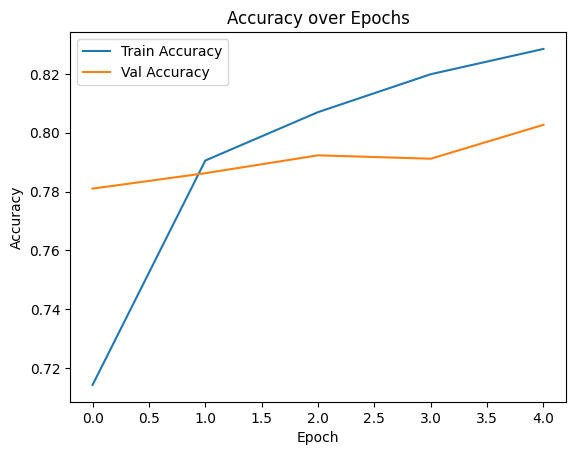

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

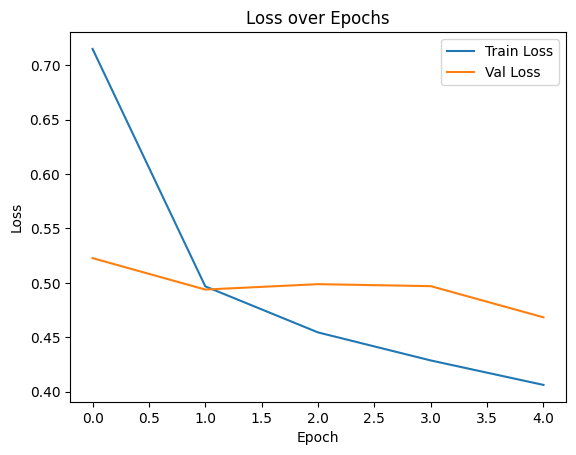

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

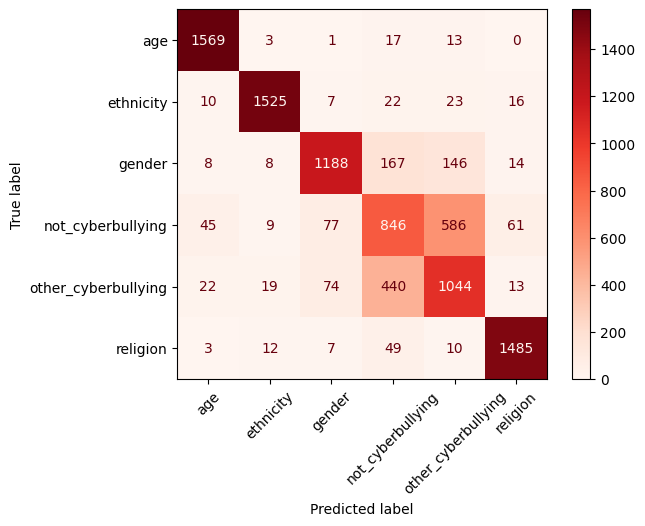

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45, cmap="Reds")

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test_enc, y_pred, output_dict=True, target_names=label_encoder.classes_)
df_report = pd.DataFrame(report).transpose().sort_values(by="f1-score", ascending=True)
df_report

,precision,recall,f1-score,support
not_cyberbullying,0.548994,0.520936,0.534597,1624.000000
other_cyberbullying,0.572997,0.647643,0.608037,1612.000000
accuracy,0.802705,0.802705,0.802705,0.802705
weighted avg,0.806273,0.802705,0.803477,9539.000000
macro avg,0.808079,0.803825,0.804928,9539.000000
gender,0.877400,0.775963,0.823570,1531.000000
religion,0.934550,0.948276,0.941363,1566.000000
ethnicity,0.967640,0.951341,0.959421,1603.000000
age,0.946892,0.978790,0.962577,1603.000000


In [ ]:
errors_df = pd.DataFrame({
    "text": X_test,
    "true": label_encoder.inverse_transform(y_test_enc),
    "pred": label_encoder.inverse_transform(y_pred)
})
misclassified = errors_df[errors_df["true"] != errors_df["pred"]]
misclassified.sample(10)

,text,true,pred
11762,have to pay if she knows he can walk way wo p...,gender,other_cyberbullying
13433,early on in my twitter life i was targeted by...,gender,other_cyberbullying
43204,rt yall niggas want somebody to be yall mom so...,ethnicity,other_cyberbullying
12815,rt,gender,other_cyberbullying
5165,are these two serious,not_cyberbullying,other_cyberbullying
27143,im trying to have a conversation why do you t...,other_cyberbullying,not_cyberbullying
6769,i also read it as a gay slur,not_cyberbullying,gender
31123,durotan and draka about to lead an army to bat...,other_cyberbullying,gender
45574,i was gonna say if the past two months have pr...,ethnicity,other_cyberbullying
6758,yes i turned on profanity filter because im tr...,not_cyberbullying,other_cyberbullying


###**BERT Modelling**

In [ ]:
# !pip -q install transformers datasets accelerate evaluate

In [ ]:
# !pip install --upgrade transformers datasets accelerate evaluate
# !pip install --upgrade peft accelerate

In [ ]:
import os
from huggingface_hub import login

login(os.getenv("HF_TOKEN"))

In [ ]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# === Setup ===
set_seed(42)
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# === Load your dataset ===
df = pd.read_csv("cyberbullying_tweets.csv")
df = df[["tweet_text", "cyberbullying_type"]].dropna()

# Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["cyberbullying_type"])

# === Split dataset ===
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
train_ds = Dataset.from_pandas(train_df[["tweet_text", "label"]].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[["tweet_text", "label"]].reset_index(drop=True))

# === Tokenization ===
def tokenize(batch):
    return tokenizer(batch["tweet_text"], truncation=True, max_length=256)

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# === Data Collator ===
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# === Load Model ===
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(le.classes_), ignore_mismatched_sizes=True)

# === Metrics ===
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# === TrainingArguments ===
training_args = TrainingArguments(
    output_dir="./cyberbert",
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

# === Trainer ===
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# === Train and Evaluate ===
trainer.train()

# === Final Evaluation ===
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = test_df["label"].values

print("\nTest Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

Map:   0%|          | 0/38153 [00:00<?, ? examples/s]

Map:   0%|          | 0/9539 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.312775,0.341372,0.868749,0.870016,0.868749,0.865649
2,0.293707,0.341179,0.874830,0.877562,0.874830,0.872251
3,0.206803,0.353975,0.873886,0.876245,0.873886,0.873198


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Test Accuracy: 0.8738861515882168

Classification Report:

                     precision    recall  f1-score   support

                age       0.99      0.98      0.99      1598
          ethnicity       0.99      0.97      0.98      1592
             gender       0.90      0.90      0.90      1595
  not_cyberbullying       0.73      0.61      0.66      1589
other_cyberbullying       0.68      0.81      0.74      1565
           religion       0.96      0.97      0.97      1600

           accuracy                           0.87      9539
          macro avg       0.88      0.87      0.87      9539
       weighted avg       0.88      0.87      0.87      9539


Confusion Matrix:
 [[1566    4    0   17   11    0]
 [   2 1550    8   10   16    6]
 [   0    3 1440   71   80    1]
 [   9    8   74  966  483   49]
 [   2    4   75  219 1263    2]
 [   1    2    3   37    6 1551]]


In [ ]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# === Setup ===
set_seed(42)
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# === Load your dataset ===
df = pd.read_csv("cyberbullying_tweets.csv")
df = df[["tweet_text", "cyberbullying_type"]].dropna()

# Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["cyberbullying_type"])

# === Split dataset ===
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
train_ds = Dataset.from_pandas(train_df[["tweet_text", "label"]].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[["tweet_text", "label"]].reset_index(drop=True))

# === Tokenization ===
def tokenize(batch):
    return tokenizer(batch["tweet_text"], truncation=True, max_length=256)

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# === Data Collator ===
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# === Load Model ===
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(le.classes_), ignore_mismatched_sizes=True)

# === Metrics ===
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# === TrainingArguments ===
training_args = TrainingArguments(
    output_dir="./cyberbert",
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

# === Trainer ===
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# === Train and Evaluate ===
trainer.train()

# === Final Evaluation ===
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = test_df["label"].values

print("\nTest Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

Map:   0%|          | 0/38153 [00:00<?, ? examples/s]

Map:   0%|          | 0/9539 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/preye/tf-metal-env/lib/python3

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.316220,0.332774,0.869378,0.868995,0.869378,0.866870
2,0.291249,0.345509,0.871370,0.871852,0.871370,0.868075
3,0.195101,0.368084,0.873676,0.874353,0.873676,0.872026


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Test Accuracy: 0.8736764860048223

Classification Report:

                     precision    recall  f1-score   support

                age       0.98      0.99      0.98      1598
          ethnicity       0.99      0.98      0.98      1592
             gender       0.89      0.91      0.90      1595
  not_cyberbullying       0.74      0.60      0.66      1589
other_cyberbullying       0.68      0.79      0.73      1565
           religion       0.96      0.97      0.97      1600

           accuracy                           0.87      9539
          macro avg       0.87      0.87      0.87      9539
       weighted avg       0.87      0.87      0.87      9539


Confusion Matrix:
 [[1575    2    0   13    8    0]
 [   4 1554    5    6   16    7]
 [   0    2 1456   58   75    4]
 [  17    6   87  949  473   57]
 [   3    4   85  228 1241    4]
 [   1    2    4   29    5 1559]]


In [ ]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# === Setup ===
set_seed(42)
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# === Load your dataset ===
df = pd.read_csv("cyberbullying_tweets.csv")
df = df[["tweet_text", "cyberbullying_type"]].dropna()

# Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["cyberbullying_type"])

# === Split dataset ===
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
train_ds = Dataset.from_pandas(train_df[["tweet_text", "label"]].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[["tweet_text", "label"]].reset_index(drop=True))

# === Tokenization ===
def tokenize(batch):
    return tokenizer(batch["tweet_text"], truncation=True, max_length=256)

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# === Data Collator ===
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# === Load Model ===
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(le.classes_), ignore_mismatched_sizes=True)

# === Metrics ===
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# === TrainingArguments ===
training_args = TrainingArguments(
    output_dir="./cyberbert",
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

# === Trainer ===
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# === Train and Evaluate ===
trainer.train()

# === Final Evaluation ===
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = test_df["label"].values

print("\nTest Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

Map:   0%|          | 0/38153 [00:00<?, ? examples/s]

Map:   0%|          | 0/9539 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.312902,0.339833,0.869483,0.871171,0.869483,0.866456
2,0.293099,0.341117,0.875354,0.877762,0.875354,0.872793
3,0.206622,0.353720,0.874201,0.876586,0.874201,0.873573


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Test Accuracy: 0.8742006499633085

Classification Report:

                     precision    recall  f1-score   support

                age       0.99      0.98      0.99      1598
          ethnicity       0.99      0.97      0.98      1592
             gender       0.90      0.90      0.90      1595
  not_cyberbullying       0.73      0.61      0.66      1589
other_cyberbullying       0.68      0.81      0.74      1565
           religion       0.97      0.97      0.97      1600

           accuracy                           0.87      9539
          macro avg       0.88      0.87      0.87      9539
       weighted avg       0.88      0.87      0.87      9539


Confusion Matrix:
 [[1565    4    0   18   11    0]
 [   2 1552    7   10   15    6]
 [   0    3 1438   74   79    1]
 [   9    8   74  968  483   47]
 [   2    4   73  219 1265    2]
 [   1    2    3   37    6 1551]]


In [ ]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# === Setup ===
set_seed(42)
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# === Load your dataset ===
df = pd.read_csv("cyberbullying_tweets.csv")
df = df[["tweet_text", "cyberbullying_type"]].dropna()

# Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["cyberbullying_type"])

# === Split dataset ===
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
train_ds = Dataset.from_pandas(train_df[["tweet_text", "label"]].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[["tweet_text", "label"]].reset_index(drop=True))

# === Tokenization ===
def tokenize(batch):
    return tokenizer(batch["tweet_text"], truncation=True, max_length=256)

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# === Data Collator ===
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# === Load Model ===
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(le.classes_), ignore_mismatched_sizes=True)

# === Metrics ===
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# === TrainingArguments ===
training_args = TrainingArguments(
    output_dir="./cyberbert",
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

# === Trainer ===
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# === Train and Evaluate ===
trainer.train()

# === Final Evaluation ===
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = test_df["label"].values

print("\nTest Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

Map:   0%|          | 0/38153 [00:00<?, ? examples/s]

Map:   0%|          | 0/9539 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.313802,0.340593,0.867491,0.869062,0.867491,0.864698
2,0.292512,0.342662,0.874096,0.876049,0.874096,0.871456
3,0.207315,0.355639,0.872733,0.875017,0.872733,0.872028


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Test Accuracy: 0.8727329908795471

Classification Report:

                     precision    recall  f1-score   support

                age       0.99      0.98      0.98      1598
          ethnicity       0.99      0.97      0.98      1592
             gender       0.90      0.90      0.90      1595
  not_cyberbullying       0.73      0.60      0.66      1589
other_cyberbullying       0.68      0.81      0.74      1565
           religion       0.96      0.97      0.97      1600

           accuracy                           0.87      9539
          macro avg       0.87      0.87      0.87      9539
       weighted avg       0.88      0.87      0.87      9539


Confusion Matrix:
 [[1566    4    0   18   10    0]
 [   2 1550    8   10   16    6]
 [   0    2 1438   73   81    1]
 [  10    7   78  961  484   49]
 [   3    4   75  222 1260    1]
 [   1    2    3   37    7 1550]]


#**LLMs**

In [ ]:
pip install transformers datasets peft accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 4.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [bitsandbytes]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("cyberbullying_tweets.csv")
df = df[["tweet_text", "cyberbullying_type"]].dropna()

# Train/test split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["cyberbullying_type"],
    random_state=42
)

# Instruction formatter
def format_instruction(tweet, label=None):
    prompt = f"""Classify the tweet into one category:
age, ethnicity, gender, religion, other_cyberbullying, not_cyberbullying.

Tweet: "{tweet}"

Answer with only the label."""

    if label is not None:
        return prompt + f" {label}"
    return prompt

# Create train text (prompt + answer)
train_df["text"] = train_df.apply(
    lambda row: format_instruction(row["tweet_text"], row["cyberbullying_type"]),
    axis=1
)

# Create test prompt only (no label appended)
test_df["prompt"] = test_df["tweet_text"].apply(
    lambda x: format_instruction(x)
)

# Keep label separately for evaluation
test_df["label"] = test_df["cyberbullying_type"]

# Save if needed
train_df[["text"]].to_csv("tinyllama_train.csv", index=False)
test_df[["prompt", "label"]].to_csv("tinyllama_test.csv", index=False)

print(train_df[["text"]].head(2))
print(test_df[["prompt", "label"]].head(2))

                                                    text
25790  Classify the tweet into one category:\nage, et...
30766  Classify the tweet into one category:\nage, et...
                                                  prompt     label
22358  Classify the tweet into one category:\nage, et...  religion
17359  Classify the tweet into one category:\nage, et...  religion


In [ ]:
print(train_df["cyberbullying_type"].value_counts())
print(test_df["label"].value_counts())

cyberbullying_type
religion               6398
age                    6394
gender                 6378
ethnicity              6369
not_cyberbullying      6356
other_cyberbullying    6258
Name: count, dtype: int64
label
religion               1600
age                    1598
gender                 1595
ethnicity              1592
not_cyberbullying      1589
other_cyberbullying    1565
Name: count, dtype: int64


In [ ]:
import torch
torch.backends.mps.is_available()

True

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)

print("Model loaded on:", device)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded on: mps


In [ ]:
train_dataset = load_dataset(
    "csv",
    data_files="tinyllama_train.csv"
)["train"]

test_dataset = load_dataset(
    "csv",
    data_files="tinyllama_test.csv"
)["train"]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
print(train_dataset[0])
print(test_dataset[0])

{'text': 'Classify the tweet into one category:\nage, ethnicity, gender, religion, other_cyberbullying, not_cyberbullying.\n\nTweet: "@scotsmiler13 @Independent It is a very very fucking bad idea to say terrible lies about your allies. see?"\n\nAnswer with only the label. other_cyberbullying'}
{'prompt': 'Classify the tweet into one category:\nage, ethnicity, gender, religion, other_cyberbullying, not_cyberbullying.\n\nTweet: "You are an idiot.Death has no time for anyone. You can die tomorrow too.. You idiots hatred for Muslims and Northerners is Crystal clear .You rejoice at their death,no wonder u r always descending in life all day. Stupid"\n\nAnswer with only the label.', 'label': 'religion'}


In [ ]:
def tokenize_train(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

tokenized_train = train_dataset.map(tokenize_train, batched=True)

Map:   0%|          | 0/38153 [00:00<?, ? examples/s]

In [ ]:
def tokenize_test(example):
    return tokenizer(
        example["prompt"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

tokenized_test = test_dataset.map(tokenize_test, batched=True)

Map:   0%|          | 0/9539 [00:00<?, ? examples/s]

In [ ]:
len(train_dataset), len(test_dataset)

(38153, 9539)

## Reduced Set for running TinyLlama

In [ ]:
reduced_train_df = (
    train_df.groupby("cyberbullying_type", group_keys=False)
            .apply(lambda x: x.sample(n=min(len(x), 2000), random_state=42))
            .reset_index(drop=True)
)

/var/folders/hl/dj9thg8x32s0k_y7xd2yfrgr0000gn/T/ipykernel_38081/1749954667.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 2000), random_state=42))


In [ ]:
print(reduced_train_df.head())
print("\nClass distribution:\n")
print(reduced_train_df["cyberbullying_type"].value_counts())
print("\nTotal rows:", len(reduced_train_df))

                                          tweet_text cyberbullying_type  \
0  I said to my wife the other day that what driv...                age   
1  me: why are people attracted to dumbasshole ci...                age   
2  today I got straight up bullied by fellow univ...                age   
3  I feel like if I stood up to my bullies in mid...                age   
4                                 School bully vibes                age   

                                                text  
0  Classify the tweet into one category:\nage, et...  
1  Classify the tweet into one category:\nage, et...  
2  Classify the tweet into one category:\nage, et...  
3  Classify the tweet into one category:\nage, et...  
4  Classify the tweet into one category:\nage, et...  

Class distribution:

cyberbullying_type
age                    2000
ethnicity              2000
gender                 2000
not_cyberbullying      2000
other_cyberbullying    2000
religion               2000
Name: coun

In [ ]:
def format_instruction(tweet, label=None):
    prompt = f"""Classify the tweet into one category:
age, ethnicity, gender, religion, other_cyberbullying, not_cyberbullying.

Tweet: "{tweet}"

Answer:"""

    if label is not None:
        return prompt + f" {label}"
    return prompt


reduced_train_df["text"] = reduced_train_df.apply(
    lambda row: format_instruction(row["tweet_text"], row["cyberbullying_type"]),
    axis=1
)

reduced_train_df[["text"]].to_csv("tinyllama_train.csv", index=False)

In [ ]:
len(reduced_train_df)

12000

In [ ]:
def format_instruction(tweet, label=None):
    prompt = f"""Classify the tweet into one category:
age, ethnicity, gender, religion, other_cyberbullying, not_cyberbullying.

Tweet: "{tweet}"

Answer:"""

    if label is not None:
        return prompt + f" {label}"
    return prompt

# Build TinyLlama training text
reduced_train_df["text"] = reduced_train_df.apply(
    lambda row: format_instruction(row["tweet_text"], row["cyberbullying_type"]),
    axis=1
)

# Save reduced train file
reduced_train_df[["text"]].to_csv("tinyllama_train.csv", index=False)

print(reduced_train_df[["text"]].head(2))

                                                text
0  Classify the tweet into one category:\nage, et...
1  Classify the tweet into one category:\nage, et...


In [ ]:
test_df["prompt"] = test_df["tweet_text"].apply(lambda x: format_instruction(x))
test_df["label"] = test_df["cyberbullying_type"]

test_df[["prompt", "label"]].to_csv("tinyllama_test.csv", index=False)

print(test_df[["prompt", "label"]].head(2))

                                                  prompt     label
22358  Classify the tweet into one category:\nage, et...  religion
17359  Classify the tweet into one category:\nage, et...  religion


In [ ]:
from datasets import load_dataset

train_dataset = load_dataset("csv", data_files="tinyllama_train.csv")["train"]
test_dataset = load_dataset("csv", data_files="tinyllama_test.csv")["train"]

print(train_dataset[0])
print(test_dataset[0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

{'text': 'Classify the tweet into one category:\nage, ethnicity, gender, religion, other_cyberbullying, not_cyberbullying.\n\nTweet: "I said to my wife the other day that what drives me is the idea that my high school bully’s children might become super fans and he will have to listen to them talk about me all the time."\n\nAnswer: age'}
{'prompt': 'Classify the tweet into one category:\nage, ethnicity, gender, religion, other_cyberbullying, not_cyberbullying.\n\nTweet: "You are an idiot.Death has no time for anyone. You can die tomorrow too.. You idiots hatred for Muslims and Northerners is Crystal clear .You rejoice at their death,no wonder u r always descending in life all day. Stupid"\n\nAnswer:', 'label': 'religion'}


In [ ]:
def tokenize_train(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

def tokenize_test(example):
    return tokenizer(
        example["prompt"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_train = train_dataset.map(tokenize_train, batched=True)
tokenized_test = test_dataset.map(tokenize_test, batched=True)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/9539 [00:00<?, ? examples/s]

In [ ]:
# import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)

# TinyLlama usually needs a pad token set
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16
)

model.config.pad_token_id = tokenizer.pad_token_id
model = model.to(device)

print("Loaded on:", device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded on: mps


In [ ]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


In [ ]:
def tokenize_train(example):
    enc = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )
    enc["labels"] = enc["input_ids"].copy()
    return enc

tokenized_train = train_dataset.map(tokenize_train, batched=True)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

In [ ]:
tokenized_train = tokenized_train.remove_columns(
    [col for col in tokenized_train.column_names if col not in ["input_ids", "attention_mask", "labels"]]
)

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./tinyllama-cyberbullying",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    learning_rate=2e-4,
    logging_steps=50,
    save_strategy="epoch",
    report_to="none",
    fp16=False
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
)

trainer.train()

/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,3.178415
100,1.196815
150,1.082477
200,1.146256
250,1.107747
300,1.095665
350,1.081503
400,1.095537
450,1.180406
500,1.122876


/Users/preye/tf-metal-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=6000, training_loss=1.0860938110351563, metrics={'train_runtime': 2905.1466, 'train_samples_per_second': 8.261, 'train_steps_per_second': 2.065, 'total_flos': 1.9088894066688e+16, 'train_loss': 1.0860938110351563, 'epoch': 2.0})

## Evaluate TinyLlama on the test prompts

In [ ]:
#Define Labels
LABELS = [
    "age",
    "ethnicity",
    "gender",
    "religion",
    "other_cyberbullying",
    "not_cyberbullying"
]

In [ ]:
#Prediction function
def predict_label(prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.pad_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract only the part after "Answer:"
    if "Answer:" in decoded:
        prediction_text = decoded.split("Answer:")[-1].strip().lower()
    else:
        prediction_text = decoded.strip().lower()

    for label in LABELS:
        if label in prediction_text:
            return label

    return "unknown"

In [ ]:
test_sample = test_df.sample(n=300, random_state=42).reset_index(drop=True)

y_true = test_sample["label"].tolist()
y_pred = []

for i, row in test_sample.iterrows():
    pred = predict_label(row["prompt"])
    y_pred.append(pred)

    if i % 25 == 0:
        print(f"Done {i}/{len(test_sample)}")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Done 0/300
Done 25/300
Done 50/300
Done 75/300
Done 100/300
Done 125/300
Done 150/300
Done 175/300
Done 200/300
Done 225/300
Done 250/300
Done 275/300


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, labels=LABELS))
print(confusion_matrix(y_true, y_pred, labels=LABELS))

Accuracy: 0.6066666666666667
                     precision    recall  f1-score   support

                age       0.83      0.95      0.88        40
          ethnicity       1.00      0.89      0.94        45
             gender       0.86      0.81      0.83        62
           religion       0.93      0.90      0.92        60
other_cyberbullying       0.00      0.00      0.00        44
  not_cyberbullying       0.00      0.00      0.00        49

          micro avg       0.90      0.61      0.73       300
          macro avg       0.60      0.59      0.60       300
       weighted avg       0.62      0.61      0.61       300

[[38  0  0  0  0  0]
 [ 2 40  0  1  0  0]
 [ 2  0 50  0  0  0]
 [ 3  0  1 54  0  0]
 [ 0  0  6  0  0  0]
 [ 1  0  1  3  0  0]]


/Users/preye/tf-metal-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/preye/tf-metal-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/preye/tf-metal-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

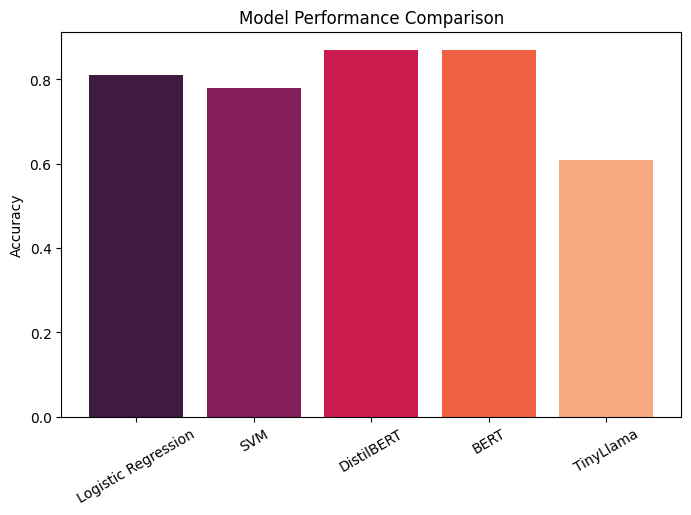

In [ ]:
import matplotlib.pyplot as plt
colors = sns.color_palette('rocket', n_colors=len(models))

models = [
    "Logistic Regression",
    "SVM",
    "DistilBERT",
    "BERT",
    "TinyLlama"
]

accuracy = [
    0.81,
    0.78,
    0.87,
    0.87,
    0.61
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy, color=colors)
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.xticks(rotation=30)
plt.show()

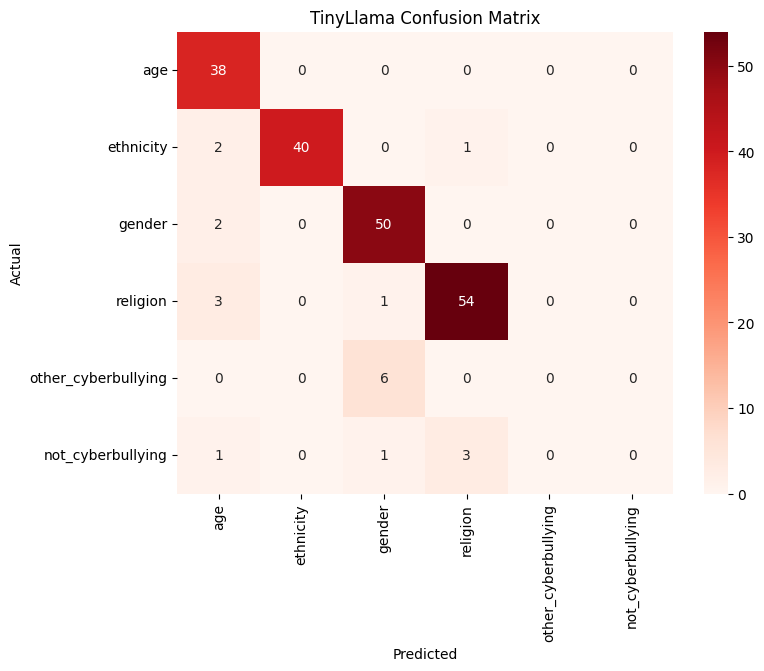

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = [
    "age",
    "ethnicity",
    "gender",
    "religion",
    "other_cyberbullying",
    "not_cyberbullying"
]

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap= 'Reds',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TinyLlama Confusion Matrix")
plt.show()


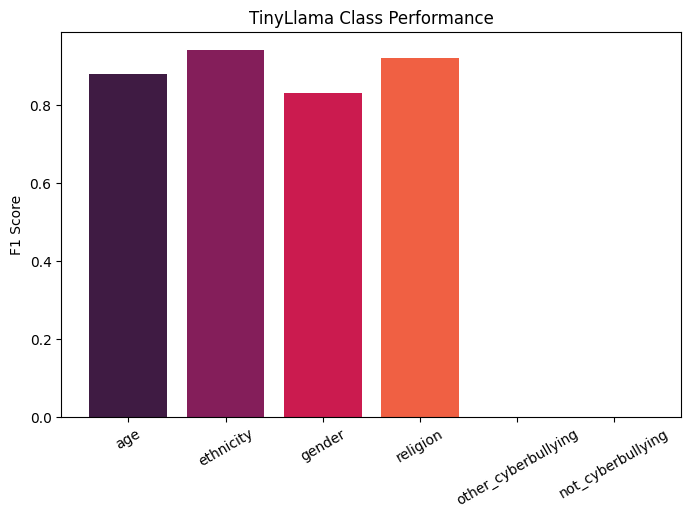

In [ ]:
import pandas as pd

f1_scores = {
    "age":0.88,
    "ethnicity":0.94,
    "gender":0.83,
    "religion":0.92,
    "other_cyberbullying":0.00,
    "not_cyberbullying":0.00
}

df = pd.DataFrame(list(f1_scores.items()), columns=["Class","F1"])

plt.figure(figsize=(8,5))
plt.bar(df["Class"], df["F1"], color=colors)
plt.ylabel("F1 Score")
plt.title("TinyLlama Class Performance")
plt.xticks(rotation=30)
plt.show()

In [ ]:
for i in range(10):
    print("Tweet:", test_sample.iloc[i]["prompt"])
    print("True:", y_true[i])
    print("Pred:", y_pred[i])
    print()

Tweet: Classify the tweet into one category:
age, ethnicity, gender, religion, other_cyberbullying, not_cyberbullying.

Tweet: "Just like rape jokes encourage rape, your "preferences" endorse what happened in #Charlottesville - you bolster gay Nazis."

Answer:
True: gender
Pred: gender

Tweet: Classify the tweet into one category:
age, ethnicity, gender, religion, other_cyberbullying, not_cyberbullying.

Tweet: "Those people who are trying to make “nigger” a norm make me fucking cringe and most of them are black . That shit is so disgusting to me . I block all of them ."

Answer:
True: ethnicity
Pred: ethnicity

Tweet: Classify the tweet into one category:
age, ethnicity, gender, religion, other_cyberbullying, not_cyberbullying.

Tweet: "@XinhBerreman I've always wanted to use that word in a sentence Xinh!😂 #mkr"

Answer:
True: not_cyberbullying
Pred: unknown

Tweet: Classify the tweet into one category:
age, ethnicity, gender, religion, other_cyberbullying, not_cyberbullying.

Tweet: 

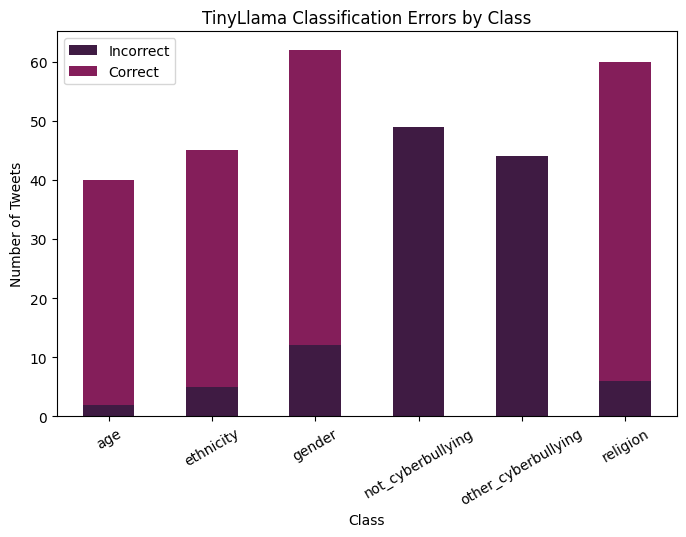

In [ ]:
results_df = pd.DataFrame({
    "prompt": test_sample["prompt"],
    "true": y_true,
    "pred": y_pred
})

results_df["correct"] = results_df["true"] == results_df["pred"]

error_stats = results_df.groupby("true")["correct"].value_counts().unstack().fillna(0)
error_stats.columns = ["Incorrect", "Correct"]

error_stats.plot(
    kind="bar",
    stacked=True,
    color= colors,
    figsize=(8,5)
)

plt.title("TinyLlama Classification Errors by Class")
plt.xlabel("Class")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=30)
plt.legend()
plt.show()

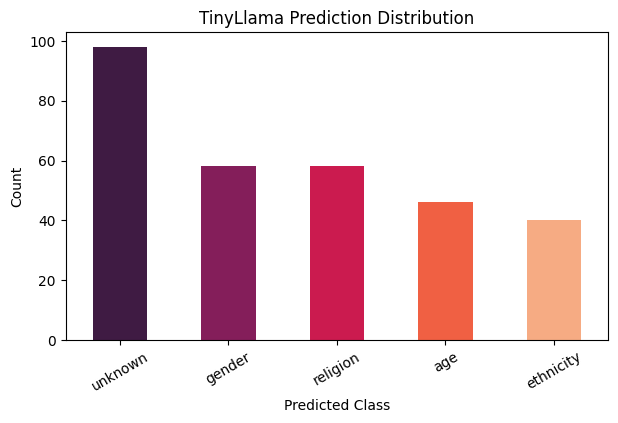

In [ ]:
pred_counts = pd.Series(y_pred).value_counts()

plt.figure(figsize=(7,4))
pred_counts.plot(kind="bar", color=colors)

plt.title("TinyLlama Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

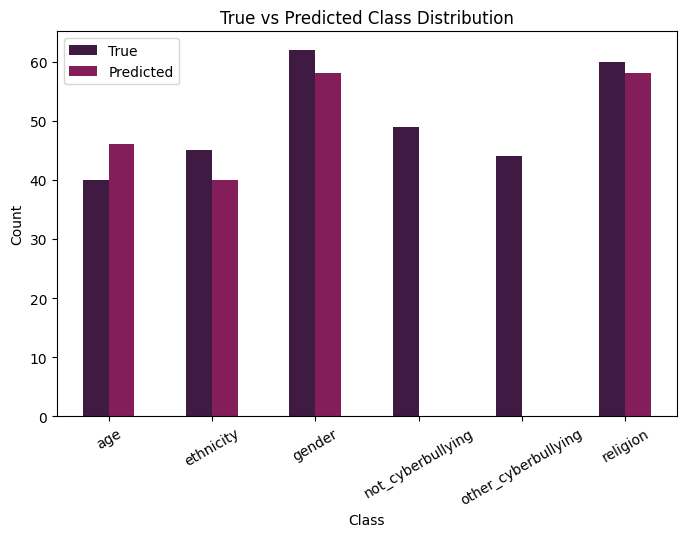

In [ ]:
true_counts = pd.Series(y_true).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().reindex(true_counts.index).fillna(0)

df_compare = pd.DataFrame({
    "True": true_counts,
    "Predicted": pred_counts,
})

df_compare.plot(kind="bar", figsize=(8,5), color=colors)

plt.title("True vs Predicted Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

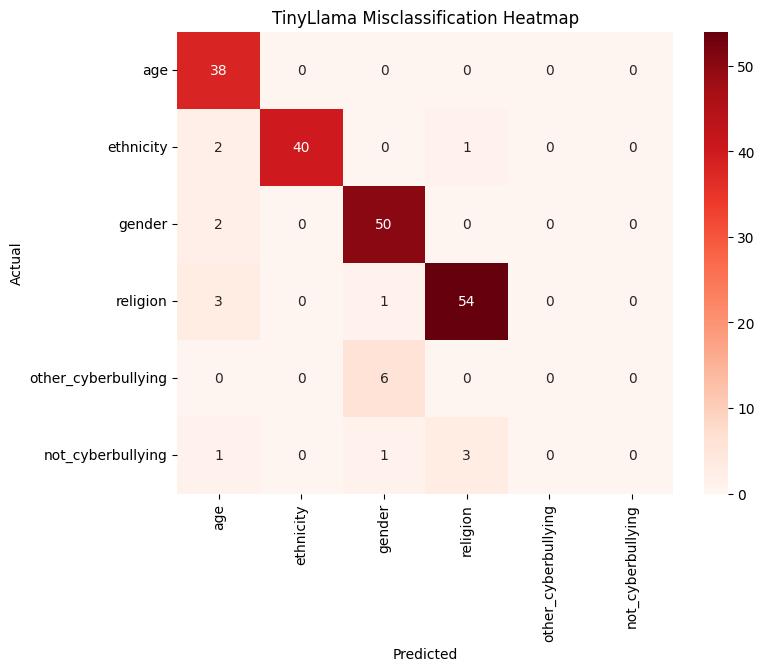

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = [
    "age",
    "ethnicity",
    "gender",
    "religion",
    "other_cyberbullying",
    "not_cyberbullying"
]

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("TinyLlama Misclassification Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

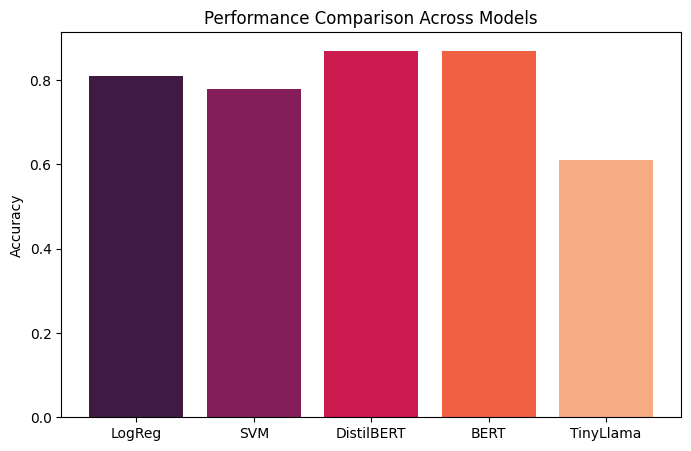

In [ ]:
models = ["LogReg","SVM","DistilBERT","BERT","TinyLlama"]
accuracy = [0.81,0.78,0.87,0.87,0.61]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy, color=colors)

plt.title("Performance Comparison Across Models")
plt.ylabel("Accuracy")

plt.show()

## LLM toxicity bias analysis

In [ ]:
identity_words = {
    "religion": ["muslim","islam","christian","jew","hindu"],
    "gender": ["woman","women","man","men","girl","boy","female","male"],
    "age": ["old","young","teen","elderly","boomer"],
    "ethnicity": ["black","white","asian","arab","african","latino"]
}

In [ ]:
def detect_identity(text):
    text = text.lower()

    for category, words in identity_words.items():
        for w in words:
            if w in text:
                return category
    return "none"

In [ ]:
def extract_tweet(prompt):
    return prompt.split("Tweet:")[1].split("Answer:")[0].strip()

In [ ]:
results_df["tweet"] = results_df["prompt"].apply(extract_tweet)
results_df["identity_group"] = results_df["tweet"].apply(detect_identity)
results_df["correct"] = results_df["true"] == results_df["pred"]

In [ ]:
print(results_df.columns)

Index(['prompt', 'true', 'pred', 'correct', 'tweet', 'identity_group'], dtype='object')


In [ ]:
results_df.head()

,prompt,true,pred,correct,tweet,identity_group
0,"Classify the tweet into one category:\nage, et...",gender,gender,True,"""Just like rape jokes encourage rape, your ""pr...",none
1,"Classify the tweet into one category:\nage, et...",ethnicity,ethnicity,True,"""Those people who are trying to make “nigger” ...",ethnicity
2,"Classify the tweet into one category:\nage, et...",not_cyberbullying,unknown,False,"""@XinhBerreman I've always wanted to use that ...",gender
3,"Classify the tweet into one category:\nage, et...",other_cyberbullying,unknown,False,"""@ludist absolutely. :) i'm still cracking up...",none
4,"Classify the tweet into one category:\nage, et...",age,age,True,"""A ver, que hay cosas peores: ""HP Lovecraft me...",gender


In [ ]:
results_df[results_df["correct"] == False].head(10)

,prompt,true,pred,correct,tweet,identity_group
2,"Classify the tweet into one category:\nage, et...",not_cyberbullying,unknown,False,"""@XinhBerreman I've always wanted to use that ...",gender
3,"Classify the tweet into one category:\nage, et...",other_cyberbullying,unknown,False,"""@ludist absolutely. :) i'm still cracking up...",none
7,"Classify the tweet into one category:\nage, et...",other_cyberbullying,gender,False,"""If you compare being #feminist with the holoc...",none
8,"Classify the tweet into one category:\nage, et...",gender,unknown,False,"""RT @SimplyCheecky: Wouldn't it nice if Annie ...",none
9,"Classify the tweet into one category:\nage, et...",other_cyberbullying,unknown,False,"""@GentlerMouse tell her that it's a gaming con...",ethnicity
14,"Classify the tweet into one category:\nage, et...",other_cyberbullying,unknown,False,"""LOL NOPE""",none
17,"Classify the tweet into one category:\nage, et...",gender,unknown,False,"""@susanhaggard1 @sara771987 Telling him to get...",none
20,"Classify the tweet into one category:\nage, et...",other_cyberbullying,unknown,False,"""RT @teenagewave: These cookies are fucking di...",age
21,"Classify the tweet into one category:\nage, et...",gender,unknown,False,"""@ChubsSays ...for life. Yes.""",none
23,"Classify the tweet into one category:\nage, et...",ethnicity,age,False,"""JOE BIDEN LABELS HISPANICS AS LATINEX WTF IF ...",gender


In [ ]:
LABELS = [
    "age",
    "ethnicity",
    "gender",
    "religion",
    "other_cyberbullying",
    "not_cyberbullying"
]

def predict_label_with_raw(prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "Answer:" in decoded:
        prediction_text = decoded.split("Answer:")[-1].strip().lower()
    else:
        prediction_text = decoded.strip().lower()

    pred_label = "unknown"
    for label in LABELS:
        if label in prediction_text:
            pred_label = label
            break

    return pred_label, prediction_text

In [ ]:
y_pred = []
raw_outputs = []

for i, row in test_sample.iterrows():
    pred_label, raw_text = predict_label_with_raw(row["prompt"])
    y_pred.append(pred_label)
    raw_outputs.append(raw_text)

In [ ]:
results_df = pd.DataFrame({
    "prompt": test_sample["prompt"],
    "true": y_true,
    "pred": y_pred,
    "raw_output": raw_outputs
})

results_df["tweet"] = results_df["prompt"].apply(extract_tweet)
results_df["identity_group"] = results_df["tweet"].apply(detect_identity)
results_df["correct"] = results_df["true"] == results_df["pred"]

In [ ]:
print(results_df["pred"].value_counts(dropna=False))

pred
religion               60
gender                 59
other_cyberbullying    51
age                    46
ethnicity              42
not_cyberbullying      42
Name: count, dtype: int64


In [ ]:
results_df[results_df["pred"] == "unknown"][["tweet", "true", "raw_output"]].head(20)

,tweet,true,raw_output


In [ ]:
error_by_group = (
    results_df.groupby("identity_group")["correct"]
    .apply(lambda x: 1 - x.mean())
    .sort_values(ascending=False)
)

print(error_by_group)

identity_group
none         0.268657
gender       0.240964
ethnicity    0.200000
religion     0.100000
age          0.000000
Name: correct, dtype: float64


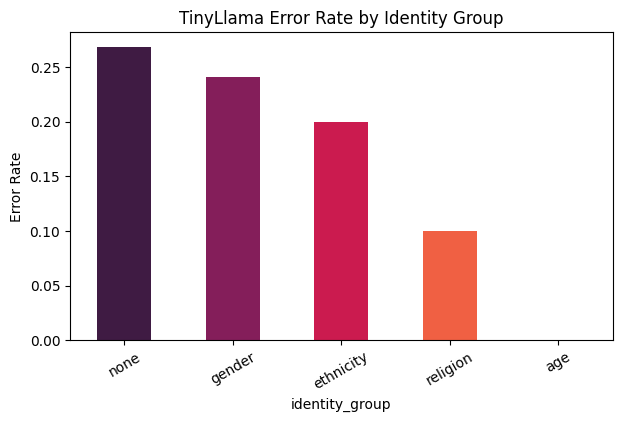

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
error_by_group.plot(kind="bar", color=colors)
plt.ylabel("Error Rate")
plt.title("TinyLlama Error Rate by Identity Group")
plt.xticks(rotation=30)
plt.show()

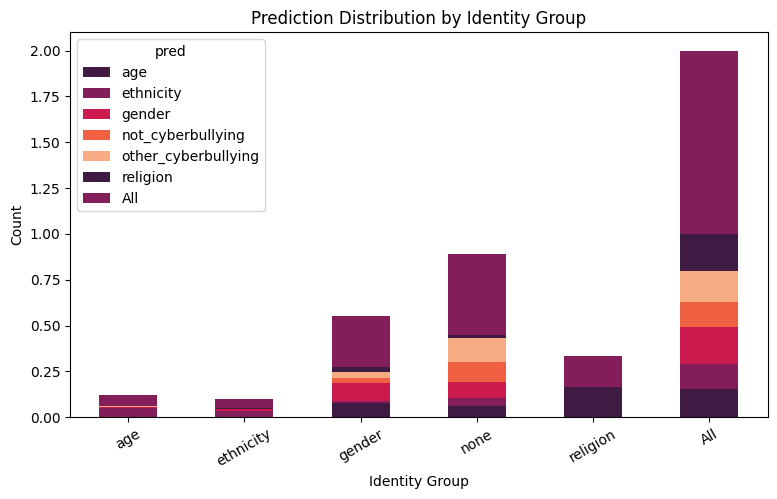

In [ ]:
bias_stats = pd.crosstab(results_df["identity_group"], results_df["pred"], normalize=True, margins=True)

bias_stats.plot(kind="bar", stacked=True, figsize=(9,5), color=colors)
plt.title("Prediction Distribution by Identity Group")
plt.xlabel("Identity Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Only look at mistakes
errors = results_df[results_df["correct"] == False]

# Count mistakes by identity group and true class
failure_map = pd.crosstab(
    errors["identity_group"],
    errors["true"]
)

print(failure_map)

true            age  ethnicity  gender  not_cyberbullying  \
identity_group                                              
ethnicity         0          2       0                  0   
gender            1          2       6                  9   
none              1          0       5                 14   
religion          0          0       0                  2   

true            other_cyberbullying  religion  
identity_group                                 
ethnicity                         1         0  
gender                            2         0  
none                             15         1  
religion                          0         3  


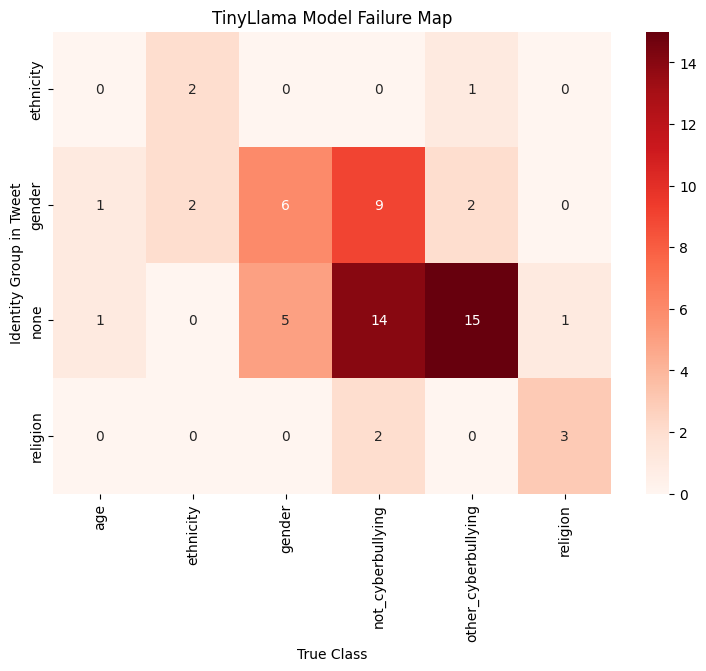

In [ ]:
plt.figure(figsize=(9,6))

sns.heatmap(
    failure_map,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("TinyLlama Model Failure Map")
plt.xlabel("True Class")
plt.ylabel("Identity Group in Tweet")

plt.show()

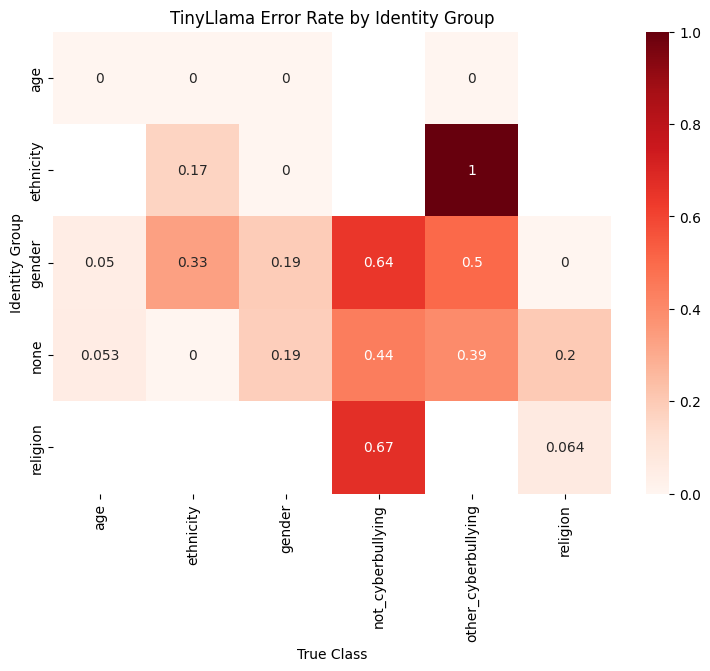

In [ ]:
failure_rate = (
    results_df
    .groupby(["identity_group","true"])["correct"]
    .apply(lambda x: 1 - x.mean())
    .unstack()
)

plt.figure(figsize=(9,6))

sns.heatmap(
    failure_rate,
    annot=True,
    cmap="Reds"
)

plt.title("TinyLlama Error Rate by Identity Group")
plt.xlabel("True Class")
plt.ylabel("Identity Group")

plt.show()